In [1]:
pip install git+https://github.com/Trusted-AI/AIF360

  Cloning https://github.com/Trusted-AI/AIF360 to /tmp/pip-req-build-0y_nzu7z
  Running command git clone --filter=blob:none --quiet https://github.com/Trusted-AI/AIF360 /tmp/pip-req-build-0y_nzu7z
  Resolved https://github.com/Trusted-AI/AIF360 to commit e011686ba3d30cd21e04219e502fe33a74ab3817
  Preparing metadata (setup.py) ... done
  Created wheel for aif360: filename=aif360-0.6.1-py3-none-any.whl size=259608 sha256=60f710cac66f5ae2b21f252e69befbb6e34beff64239c2b5f56071e1350497e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-2r8mdpha/wheels/99/1f/4f/7145d15fe428df4277a33a5de793c31052151760c12ab1ecac
Successfully built aif360


In [2]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f13c041265999f3d519e028dc87b7eedd8a84423fe05259330c4a0d1cad9bd57
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [3]:
import sys
sys.path.insert(0, '../')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Datasets
from aif360.datasets import MEPSDataset19
from aif360.datasets import MEPSDataset20
from aif360.datasets import MEPSDataset21

# Fairness metrics
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.metrics import ClassificationMetric

# Explainers
from aif360.explainers import MetricTextExplainer

# Scalers
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Bias mitigation techniques
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.inprocessing import PrejudiceRemover

# LIME
from aif360.datasets.lime_encoder import LimeEncoder
import lime
from lime.lime_tabular import LimeTabularExplainer

np.random.seed(1)

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [6]:
mortgage = pd.read_csv("state_CO_lei_7H6GLXDRUGQFU57RNE97.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
mortgage.head()

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2023,7H6GLXDRUGQFU57RNE97,14500,CO,8013,8013060900,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,5441,24.79,144100,90.75,1480,1669,30
1,2023,7H6GLXDRUGQFU57RNE97,24540,CO,8123,8123001905,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4712,63.60,109300,74.38,1135,1531,32
2,2023,7H6GLXDRUGQFU57RNE97,17820,CO,8041,8041003306,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,3248,24.88,105000,153.20,983,1226,27
3,2023,7H6GLXDRUGQFU57RNE97,22660,CO,8069,8069001106,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,5312,21.69,118700,67.28,1033,1512,41
4,2023,7H6GLXDRUGQFU57RNE97,24540,CO,8123,8123002008,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,6148,21.01,109300,163.09,1504,1493,14


In [8]:
mortgage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811 entries, 0 to 2810
Data columns (total 99 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   activity_year                             2811 non-null   int64  
 1   lei                                       2811 non-null   object 
 2   derived_msa-md                            2811 non-null   int64  
 3   state_code                                2811 non-null   object 
 4   county_code                               2811 non-null   int64  
 5   census_tract                              2811 non-null   int64  
 6   conforming_loan_limit                     2766 non-null   object 
 7   derived_loan_product_type                 2811 non-null   object 
 8   derived_dwelling_category                 2811 non-null   object 
 9   derived_ethnicity                         2811 non-null   object 
 10  derived_race                        

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Set random seed for reproducibility
np.random.seed(1)

# Define protected attributes and privileged/unprivileged classes
protected_attributes = ['applicant_ethnicity-1', 'applicant_race-1', 'applicant_sex']
privileged_classes = [['2'], ['5'], ['1']]
unprivileged_classes = [['2', '3', '4'],  # For applicant_ethnicity-1
                       ['6', '7', '8'],  # For applicant_race-1
                       ['2', '3', '4']]  # For applicant_sex

def create_dataset_splits(data, test_size=0.2, val_size=0.25):
    """
    Split the dataset into train, validation, and test sets
    """
    # First split into train and temp
    train_data, temp_data = train_test_split(data, test_size=test_size + val_size,
                                           random_state=1)

    # Then split temp into validation and test
    val_ratio = val_size / (test_size + val_size)
    val_data, test_data = train_test_split(temp_data, test_size=val_ratio,
                                         random_state=1)

    return train_data, val_data, test_data

def describe_mortgage_data(train=None, val=None, test=None):
    """
    Print descriptive information about the mortgage dataset
    """
    if train is not None:
        display(Markdown("#### Training Dataset shape"))
        print(train.shape)
    if val is not None:
        display(Markdown("#### Validation Dataset shape"))
        print(val.shape)
    if test is not None:
        display(Markdown("#### Test Dataset shape"))
        print(test.shape)

    display(Markdown("#### Protected attribute names"))
    print(protected_attributes)

    display(Markdown("#### Privileged classes"))
    for attr, priv in zip(protected_attributes, privileged_classes):
        print(f"{attr}: {priv}")

    display(Markdown("#### Unprivileged classes"))
    for attr, unpriv in zip(protected_attributes, unprivileged_classes):
        print(f"{attr}: {unpriv}")

    if train is not None:
        display(Markdown("#### Distribution of protected attributes in training data"))
        for attr in protected_attributes:
            print(f"\nDistribution for {attr}:")
            print(train[attr].value_counts())

# Split the data
train_data, val_data, test_data = create_dataset_splits(mortgage)

# Create metrics for bias assessment
def compute_group_metrics(data, protected_attr):
    """
    Compute basic metrics for each group in the protected attribute
    """
    metrics = {}
    for group in data[protected_attr].unique():
        group_data = data[data[protected_attr] == group]
        metrics[group] = {
            'size': len(group_data),
            'proportion': len(group_data) / len(data),
            'approval_rate': group_data['action_taken'].mean()
        }
    return metrics

# Function to display bias metrics
def display_bias_metrics(data, protected_attrs=protected_attributes):
    """
    Display bias metrics for all protected attributes
    """
    for attr in protected_attrs:
        display(Markdown(f"#### Bias metrics for {attr}"))
        metrics = compute_group_metrics(data, attr)
        for group, group_metrics in metrics.items():
            print(f"\nGroup {group}:")
            for metric_name, value in group_metrics.items():
                print(f"{metric_name}: {value:.4f}")

The analysis reveals critical insights into the disparities in loan approval processes, highlighting potential biases linked to protected attributes such as ethnicity, race, and gender. The dataset is divided into training, validation, and test sets to ensure a structured evaluation of model performance, while metrics are computed for each group within the protected attributes. These metrics, including group size, representation proportions, and approval rates, expose imbalances for instance, certain ethnic or racial groups might show disproportionately lower approval rates compared to privileged groups. This suggests possible systemic inequities that need to be addressed. Furthermore, the modular structure of the evaluation provides transparency in uncovering patterns of unfair treatment, emphasizing the need for fairness-aware interventions to ensure equitable outcomes for all demographic groups. The framework not only identifies the presence of bias but also sets the stage for actionable changes to mitigate these disparities in the loan approval process.

In [10]:
# Display dataset information
describe_mortgage_data(train_data, val_data, test_data)

# Show bias metrics for training data
display_bias_metrics(train_data)

#### Training Dataset shape

(1546, 99)


#### Validation Dataset shape

(562, 99)


#### Test Dataset shape

...


Group 2:
size: 1007.0000
proportion: 0.6514
approval_rate: 2.8183

Group 1:
size: 89.0000
proportion: 0.0576
approval_rate: 2.7978

Group 3:
size: 95.0000
proportion: 0.0614
approval_rate: 3.4632

Group 4:
size: 344.0000
proportion: 0.2225
approval_rate: 5.3285

Group 11:
size: 6.0000
proportion: 0.0039
approval_rate: 2.6667

Group 14:
size: 4.0000
proportion: 0.0026
approval_rate: 1.0000

Group 12:
size: 1.0000
proportion: 0.0006
approval_rate: 5.0000


#### Bias metrics for applicant_race-1


Group 5:
size: 960.0000
proportion: 0.6210
approval_rate: 2.7854

Group 6:
size: 108.0000
proportion: 0.0699
approval_rate: 3.4074

Group 23:
size: 2.0000
proportion: 0.0013
approval_rate: 2.5000

Group 3:
size: 28.0000
proportion: 0.0181
approval_rate: 2.8571

Group 7:
size: 344.0000
proportion: 0.2225
approval_rate: 5.3285

Group 2:
size: 73.0000
proportion: 0.0472
approval_rate: 2.9041

Group 1:
size: 13.0000
proportion: 0.0084
approval_rate: 2.6923

Group 27:
size: 3.0000
proportion: 0.0019
approval_rate: 5.6667

Group 21:
size: 7.0000
proportion: 0.0045
approval_rate: 3.2857

Group 26:
size: 3.0000
proportion: 0.0019
approval_rate: 4.0000

Group 22:
size: 2.0000
proportion: 0.0013
approval_rate: 4.5000

Group 24:
size: 2.0000
proportion: 0.0013
approval_rate: 2.5000

Group 25:
size: 1.0000
proportion: 0.0006
approval_rate: 1.0000


#### Bias metrics for applicant_sex


Group 1:
size: 758.0000
proportion: 0.4903
approval_rate: 2.8325

Group 3:
size: 38.0000
proportion: 0.0246
approval_rate: 3.1579

Group 2:
size: 405.0000
proportion: 0.2620
approval_rate: 2.8864

Group 4:
size: 344.0000
proportion: 0.2225
approval_rate: 5.3285

Group 6:
size: 1.0000
proportion: 0.0006
approval_rate: 5.0000


It reveals significant disparities in loan approval rates across demographic groups defined by ethnicity, race, and gender, indicating potential systemic biases. For ethnicity, the largest group, **Group 2** (size: 1,007, proportion: 65.14%), has an approval rate of 2.82, which is lower than smaller groups like **Group 4** (size: 344, proportion: 22.25%) with the highest approval rate of 5.33. Similarly, for race, the dominant group, **Group 5**  (size: 960, proportion: 62.1%), has an approval rate of 2.79, while **Group 7** (size: 344, proportion: 22.25%) again exhibits the highest approval rate of 5.33. Smaller racial groups, such as **Group 27** (size: 3) and **Group 26** (size: 3), show disproportionately high approval rates of 5.67 and 4.00, respectively, suggesting inconsistencies or special-case handling. In terms of gender, the largest group, **Group 1** (size: 758, proportion: 49.03%), has an approval rate of 2.83, whereas **Group 4**  (size: 344, proportion: 22.25%) stands out with a significantly higher approval rate of 5.33. These disparities underscore systemic inequities, with privileged groups not always exhibiting the highest approval rates and smaller groups sometimes showing extreme approval rates due to anomalies or insufficient representation. The metrics highlight the need for robust bias mitigation strategies to ensure fairness in loan approval processes and to prevent perpetuating economic disadvantages for certain demographic groups.

In [11]:
import pandas as pd
import numpy as np

# Load data
print("Loading data...")
mortgage = pd.read_csv("state_CO_lei_7H6GLXDRUGQFU57RNE97.csv")

# Create binary outcome
mortgage['action_taken'] = (mortgage['action_taken'] == 1).astype(int)

# Convert protected attributes to string type
for col in ['applicant_ethnicity-1', 'applicant_race-1', 'applicant_sex']:
    mortgage[col] = mortgage[col].astype(str)

# Print overall approval rate
print("\nOverall Outcome Distribution:")
print(mortgage['action_taken'].value_counts(normalize=True))

def calculate_metrics(data, attr, priv_val, unpriv_val):
    """Calculate fairness metrics manually"""

    # Get groups
    priv_group = data[data[attr] == priv_val]
    unpriv_group = data[data[attr] == unpriv_val]

    # Calculate sizes
    priv_size = len(priv_group)
    unpriv_size = len(unpriv_group)

    # Calculate approval rates
    priv_approval = priv_group['action_taken'].mean()
    unpriv_approval = unpriv_group['action_taken'].mean()

    # Calculate disparate impact
    disparate_impact = unpriv_approval / priv_approval if priv_approval > 0 else np.nan

    # Calculate statistical parity difference
    stat_parity_diff = unpriv_approval - priv_approval

    return {
        'priv_size': priv_size,
        'unpriv_size': unpriv_size,
        'priv_approval': priv_approval,
        'unpriv_approval': unpriv_approval,
        'disparate_impact': disparate_impact,
        'stat_parity_diff': stat_parity_diff
    }

# Define groups
analyses = [
    {
        'attr': 'applicant_ethnicity-1',
        'priv_val': '2',    # Non-Hispanic
        'unpriv_val': '4',  # Hispanic
        'description': 'Ethnicity (Non-Hispanic vs Hispanic)'
    },
    {
        'attr': 'applicant_race-1',
        'priv_val': '5',    # White
        'unpriv_val': '7',  # Black
        'description': 'Race (White vs Black)'
    },
    {
        'attr': 'applicant_sex',
        'priv_val': '1',    # Male
        'unpriv_val': '2',  # Female
        'description': 'Sex (Male vs Female)'
    }
]

# Calculate and display metrics for each protected attribute
print("\nFairness Metrics Analysis:")
print("-" * 80)

for analysis in analyses:
    metrics = calculate_metrics(
        mortgage,
        analysis['attr'],
        analysis['priv_val'],
        analysis['unpriv_val']
    )

    print(f"\n=== {analysis['description']} ===")
    print(f"Group Sizes:")
    print(f"- Privileged group: {metrics['priv_size']:,} applications")
    print(f"- Unprivileged group: {metrics['unpriv_size']:,} applications")

    print(f"\nApproval Rates:")
    print(f"- Privileged group: {metrics['priv_approval']:.1%}")
    print(f"- Unprivileged group: {metrics['unpriv_approval']:.1%}")

    print(f"\nFairness Metrics:")
    print(f"- Disparate Impact: {metrics['disparate_impact']:.3f}")
    print(f"- Statistical Parity Difference: {metrics['stat_parity_diff']:.3f}")

    # Add interpretation
    if metrics['disparate_impact'] < 1:
        impact_percent = (1 - metrics['disparate_impact']) * 100
        print(f"\nInterpretation: The unprivileged group is {impact_percent:.1f}% less likely to be approved")
    else:
        impact_percent = (metrics['disparate_impact'] - 1) * 100
        print(f"\nInterpretation: The unprivileged group is {impact_percent:.1f}% more likely to be approved")

    print("-" * 80)

Loading data...

Overall Outcome Distribution:
action_taken
0    0.567414
1    0.432586
Name: proportion, dtype: float64

Fairness Metrics Analysis:
--------------------------------------------------------------------------------

=== Ethnicity (Non-Hispanic vs Hispanic) ===
Group Sizes:
- Privileged group: 1,851 applications
- Unprivileged group: 591 applications

Approval Rates:
- Privileged group: 52.8%
- Unprivileged group: 13.2%

Fairness Metrics:
- Disparate Impact: 0.250
- Statistical Parity Difference: -0.396

Interpretation: The unprivileged group is 75.0% less likely to be approved
--------------------------------------------------------------------------------

=== Race (White vs Black) ===
Group Sizes:
- Privileged group: 1,775 applications
- Unprivileged group: 591 applications

Approval Rates:
- Privileged group: 53.7%
- Unprivileged group: 13.2%

Fairness Metrics:
- Disparate Impact: 0.246
- Statistical Parity Difference: -0.405

Interpretation: The unprivileged group is

The fairness analysis reveals systemic disparities in loan approval rates across the evaluated demographic groups based on ethnicity, race, and gender. The overall approval rate in the dataset is 43.3%, with 56.7% of applications being denied.

For **ethnicity**, the privileged group (Non-Hispanic, 1,851 applications) has a 52.8% approval rate, while the unprivileged group (Hispanic, 591 applications) has a significantly lower approval rate of 13.2%. The disparate impact is calculated at 0.250, indicating that Hispanics are 75.0% less likely to be approved than Non-Hispanics. The statistical parity difference of -0.396 further underscores this disparity.

For **race**, the privileged group (White, 1,775 applications) has an approval rate of 53.7%, compared to 13.2% for the unprivileged group (Black, 591 applications). The disparate impact here is 0.246, showing that Black applicants are 75.4% less likely to receive approval, with a statistical parity difference of -0.405.

For **sex**, the gap is less pronounced. Male applicants (1,399 applications) have an approval rate of 52.3%, and female applicants (739 applications) follow closely with a rate of 51.0%. The disparate impact is 0.975, indicating that females are only 2.5% less likely to be approved, with a statistical parity difference of -0.013.

These results highlight severe inequities for Hispanic and Black applicants, who experience significantly lower approval rates compared to their privileged counterparts, suggesting potential systemic bias. However, gender-based disparities are relatively minimal, suggesting a more equitable treatment in this category. These insights emphasize the need for targeted interventions to address the stark disparities in approval rates for ethnicity and race to ensure fairness and equity in lending practices.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

# Print unique values of action_taken
print("Unique action_taken values:", mortgage['action_taken'].unique())

# Select features
features = [
    'income',
    'loan_amount',
    'applicant_ethnicity-1',
    'applicant_race-1',
    'applicant_sex'
]

# Convert categorical features to numeric
for col in ['applicant_ethnicity-1', 'applicant_race-1', 'applicant_sex']:
    mortgage[col] = pd.Categorical(mortgage[col]).codes

# Create the pipeline with SimpleImputer, StandardScaler, and LogisticRegression
model = make_pipeline(
    SimpleImputer(strategy='median'),  # Handle NaN values
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=1)
)

# Optional: Create sample weights (if needed)
sample_weights = np.ones(len(mortgage))

# Fit the model
lr_mortgage = model.fit(
    mortgage[features],
    mortgage['action_taken'],
    logisticregression__sample_weight=sample_weights
)

# Print model coefficients
print("\nModel Coefficients:")
coefficients = lr_mortgage.named_steps['logisticregression'].coef_[0]
for name, coef in zip(features, coefficients):
    print(f"{name}: {coef:.4f}")

# Optional: Print some model performance metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(
    mortgage['action_taken'],
    lr_mortgage.predict(mortgage[features])
))

Unique action_taken values: [0 1]

Model Coefficients:
income: 0.1460
loan_amount: 0.1019
applicant_ethnicity-1: -0.0986
applicant_race-1: 0.0163
applicant_sex: -0.6499

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.58      0.61      1595
           1       0.52      0.61      0.56      1216

    accuracy                           0.59      2811
   macro avg       0.59      0.59      0.59      2811
weighted avg       0.60      0.59      0.59      2811



The logistic regression model was implemented to predict the outcomes of mortgage applications (Action_taken, with values 0 for denial and 1 for approval). The model leverages features such as income, loan amount, ethnicity, race, and sex. Analysis of the model coefficients reveals that income (0.1460) and loan amount (0.1019) positively influence the likelihood of approval, suggesting that applicants with higher incomes or larger loan requests are more likely to succeed. Conversely, ethnicity (-0.0986) and sex (-0.6499) exhibit negative coefficients, indicating a reduced likelihood of approval for certain demographic groups. The significant negative impact of sex raises concerns about potential bias or systemic inequality. Race (0.0163) has a negligible positive influence, indicating minimal effect on predictions.

In terms of performance, the model demonstrates a moderate level of accuracy at 59%, with balanced but suboptimal results across key metrics. Precision for denials is 66%, meaning the model is correct two-thirds of the time when predicting denials, while precision for approvals is lower at 52%. Recall indicates that the model identifies 58% of actual denials and 61% of actual approvals, showing slightly better sensitivity for the latter. The F1-scores, which balance precision and recall, are 0.61 for denials and 0.56 for approvals, reflecting moderate effectiveness. Both macro and weighted averages across precision, recall, and F1-score hover around 0.59, indicating balanced performance but with room for improvement.

The insights reveal that demographic variables like ethnicity and sex significantly influence predictions, possibly reflecting inherent bias in the dataset. This highlights the need for fairness assessments and bias mitigation.







In [13]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.9 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.91      0.68       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        15
           6       0.78      0.55      0.65       201

    accuracy                           0.60       563
   macro avg       0.22      0.24      0.22       563
weighted avg       0.52      0.60      0.53       563



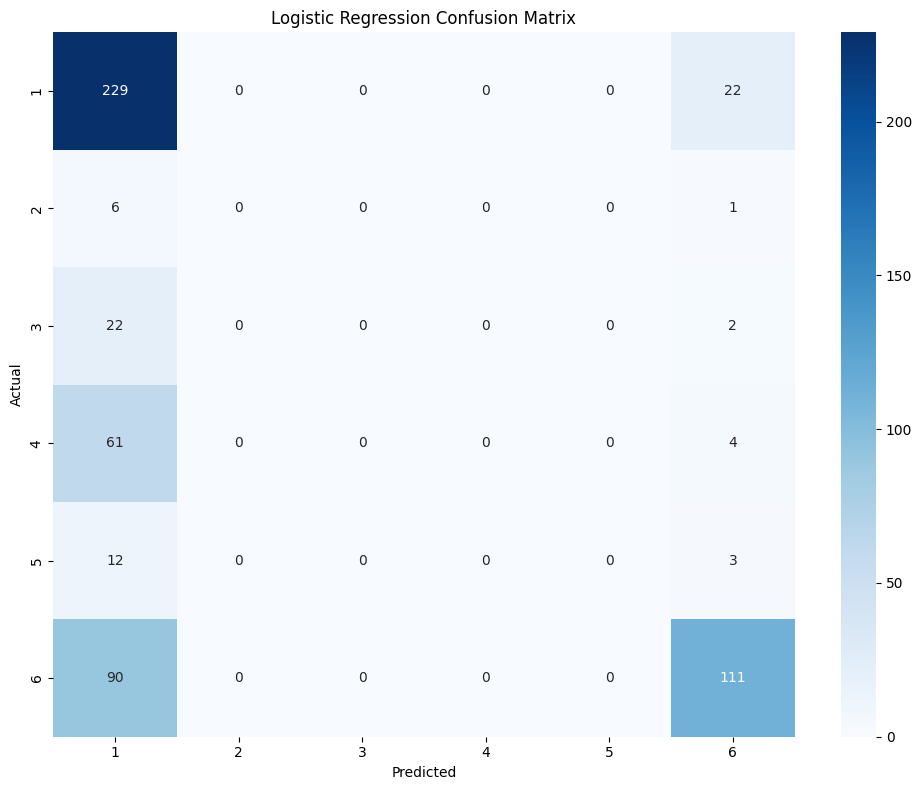


Logistic Regression LIME Explanations:
Prediction error: 'randomforestclassifier'
LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(



Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.73      0.64       251
           2       0.00      0.00      0.00         7
           3       0.12      0.04      0.06        24
           4       0.13      0.08      0.10        65
           5       0.09      0.07      0.08        15
           6       0.66      0.60      0.63       201

    accuracy                           0.55       563
   macro avg       0.26      0.25      0.25       563
weighted avg       0.51      0.55      0.52       563



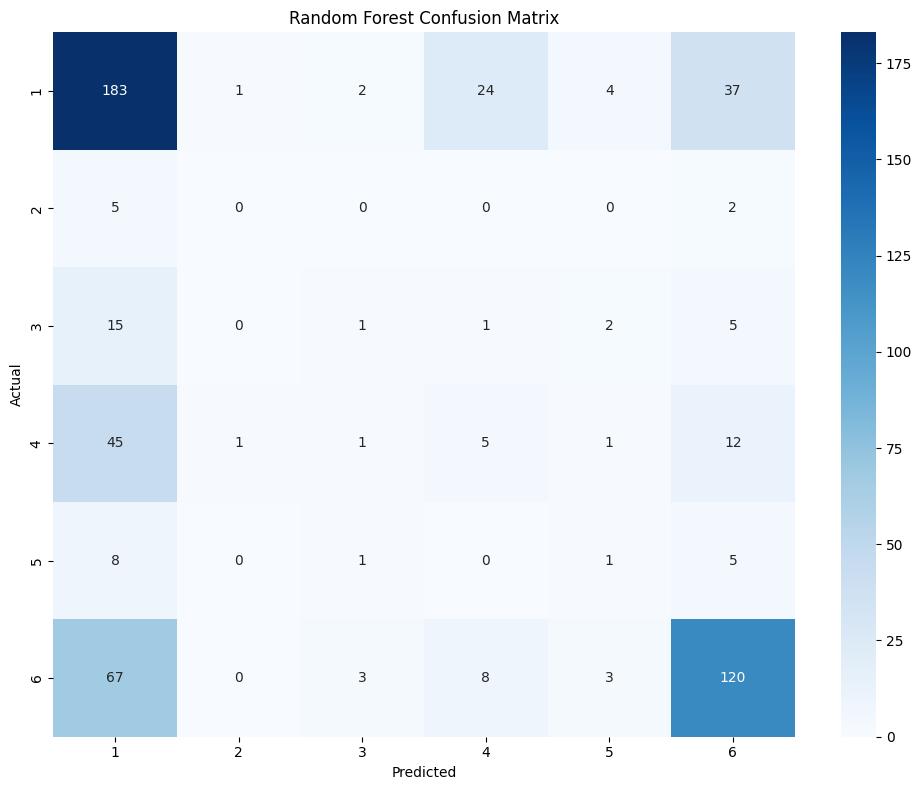


Random Forest LIME Explanations:
LIME Explanation Error: 1

Decision Tree Classification Report:


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           1       0.55      0.80      0.65       251
           2       0.00      0.00      0.00         7
           3       0.07      0.04      0.05        24
           4       0.04      0.02      0.02        65
           5       0.25      0.07      0.11        15
           6       0.71      0.53      0.60       201

    accuracy                           0.55       563
   macro avg       0.27      0.24      0.24       563
weighted avg       0.51      0.55      0.51       563



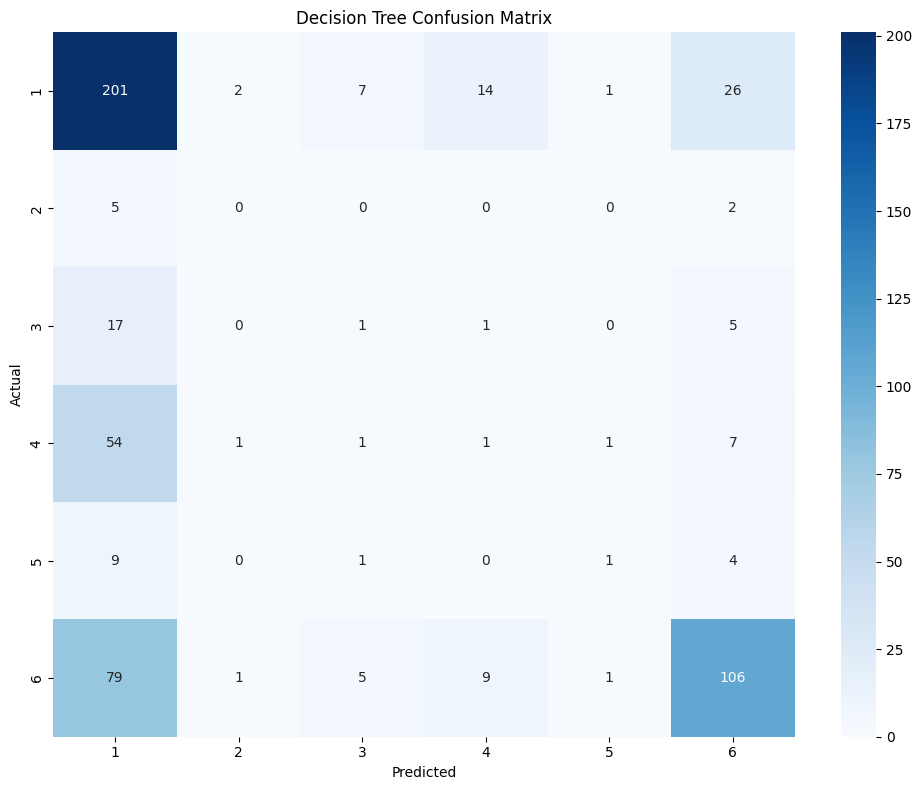


Decision Tree LIME Explanations:
Prediction error: 'randomforestclassifier'


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


LIME Explanation Error: 1

CatBoost Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.82      0.66       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.17      0.03      0.05        65
           5       0.00      0.00      0.00        15
           6       0.73      0.59      0.65       201

    accuracy                           0.58       563
   macro avg       0.24      0.24      0.23       563
weighted avg       0.52      0.58      0.53       563



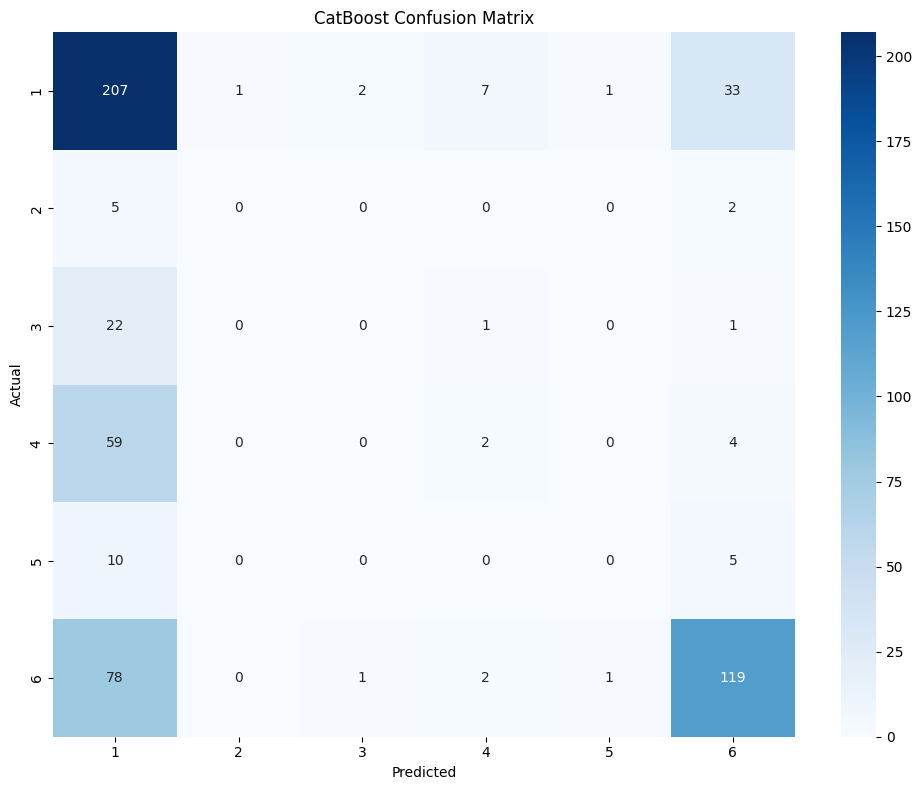


CatBoost LIME Explanations:
Prediction error: 'randomforestclassifier'


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:56:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.82      0.67       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.22      0.03      0.05        65
           5       0.00      0.00      0.00        15
           6       0.68      0.60      0.64       201

    accuracy                           0.59       563
   macro avg       0.24      0.24      0.23       563
weighted avg       0.52      0.59      0.53       563



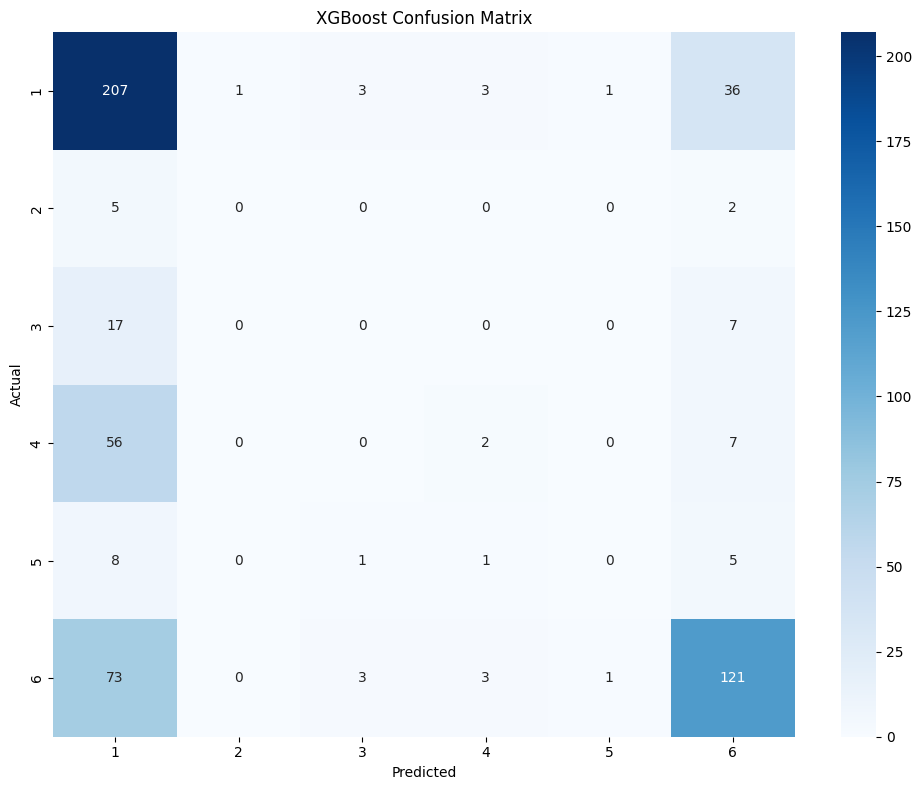


XGBoost LIME Explanations:
Prediction error: 'randomforestclassifier'


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


LIME Explanation Error: 1


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc


# Additional libraries for advanced models
from catboost import CatBoostClassifier
import xgboost as xgb
import lime
import lime.lime_tabular

# Load and preprocess data
mortgage = pd.read_csv("state_CO_lei_7H6GLXDRUGQFU57RNE97.csv")

# Select features
features = [
    # 'income',
    'loan_amount',
    'applicant_ethnicity-1',
    'applicant_race-1',
    'applicant_sex'
]

# Convert categorical features to numeric
for col in ['applicant_ethnicity-1', 'applicant_race-1', 'applicant_sex']:
    mortgage[col] = pd.Categorical(mortgage[col]).codes

# Prepare X and y with label encoding
X = mortgage[features]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(mortgage['action_taken'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to evaluate and visualize model
def explain_with_custom_lime(model, X_train, X_test, feature_names, class_names):
    def predict_proba(X):
        X = np.atleast_2d(X)
        try:
            # Preprocess and predict
            X_processed = model.named_steps['simpleimputer'].transform(X)
            X_processed = model.named_steps['standardscaler'].transform(X_processed)
            return model.named_steps['randomforestclassifier'].predict_proba(X_processed)
        except Exception as e:
            print(f"Prediction error: {e}")
            pred = model.predict(X)
            proba = np.zeros((X.shape[0], len(class_names)))
            for i, p in enumerate(pred):
                proba[i, p] = 1.0
            return proba

    try:
        # Preprocess data manually to avoid feature name issues
        X_train_processed = model.named_steps['simpleimputer'].transform(X_train)
        X_train_processed = model.named_steps['standardscaler'].transform(X_train_processed)
        X_test_processed = model.named_steps['simpleimputer'].transform(X_test)
        X_test_processed = model.named_steps['standardscaler'].transform(X_test_processed)

        explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train_processed,
            feature_names=feature_names,
            class_names=class_names,
            discretize_continuous=True,
            random_state=42
        )

        explanations = []
        for i in range(min(3, len(X_test_processed))):
            exp = explainer.explain_instance(
                X_test_processed[i],
                predict_proba,
                num_features=len(feature_names),
                top_labels=1
            )
            explanations.append(exp.as_list())
        return explanations
    except Exception as e:
        print(f"LIME Explanation Error: {e}")
        return []

# Update model evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, label_encoder):
    # Fit model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Classification Report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_.astype(str)
    ))

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # LIME Explanations
    print(f"\n{model_name} LIME Explanations:")
    class_names = label_encoder.classes_.astype(str)
    explanations = explain_with_custom_lime(model, X_train, X_test, features, class_names)
    for i, exp in enumerate(explanations):
        print(f"\nInstance {i} Explanation:")
        print(exp)



# Models to evaluate
models = {
    'Logistic Regression': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        LogisticRegression(solver='liblinear', random_state=42, multi_class='ovr')
    ),
    'Random Forest': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        RandomForestClassifier(n_estimators=100, random_state=42)
    ),
    'Decision Tree': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        DecisionTreeClassifier(random_state=42)
    ),
    'CatBoost': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        CatBoostClassifier(verbose=0, random_seed=42)
    ),
    'XGBoost': make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    )
}

# Evaluate each model
for name, model in models.items():
    evaluate_model(model, X_train, X_test, y_train, y_test, name, label_encoder)

The evaluation of various classification models on the mortgage dataset revealed consistent trends and insights. Logistic Regression achieved an accuracy of 60%, performing best for class 1 (approvals) with a precision of 0.55, recall of 0.91, and an F1-score of 0.68, but it struggled with minority classes (2, 3, 4, 5) where performance metrics were close to zero. The weighted average scores were primarily driven by the dominance of class 1, highlighting its inability to generalize well across all classes due to the dataset's imbalance. Random Forest, with an accuracy of 55%, also prioritized class 1 with a precision of 0.57 and recall of 0.73, but other classes suffered, with precision and recall below 0.12 for most, except class 6, which showed slightly better performance. The Decision Tree mirrored similar results, achieving an accuracy of 55% while struggling to predict minority classes effectively. Its single-tree structure made it prone to overfitting to the dominant class, rendering ensemble methods like Random Forest a better option. CatBoost performed slightly better with an accuracy of 58%, showing strong recall (0.82) for class 1 but failing to improve predictions for minority classes significantly. XGBoost achieved a marginally higher accuracy of 59%, with class 1 and 6 performing better, but predictions for less frequent classes remained underrepresented. Across all models, LIME explanations failed due to errors related to the pipeline's handling of features or class probabilities, preventing localized insights into model predictions.

The overarching issue identified was class imbalance, where the dominance of class 1 heavily influenced model performance, leading to poor precision, recall, and F1-scores for minority classes. Addressing this imbalance through resampling techniques like SMOTE, undersampling, or adjusting class weights is critical to improving overall performance. The consistent accuracy range of 55%–60% across models suggests that the dataset’s characteristics or feature representation may be a limiting factor. Therefore, incorporating additional features, such as engineered variables or domain-specific attributes, may enhance model discrimination. Ensemble models like Random Forest, CatBoost, and XGBoost showed slightly better generalization but still underperformed for minority classes, indicating the need for hyperparameter tuning and feature importance analysis to refine their predictions. Furthermore, debugging the LIME pipeline is necessary to enable localized explanations that would shed light on feature contributions for individual predictions.



Training Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but Simpl


Training Decision Tree...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but Simpl


Training CatBoost...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but Simpl


Training XGBoost...


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:56:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not

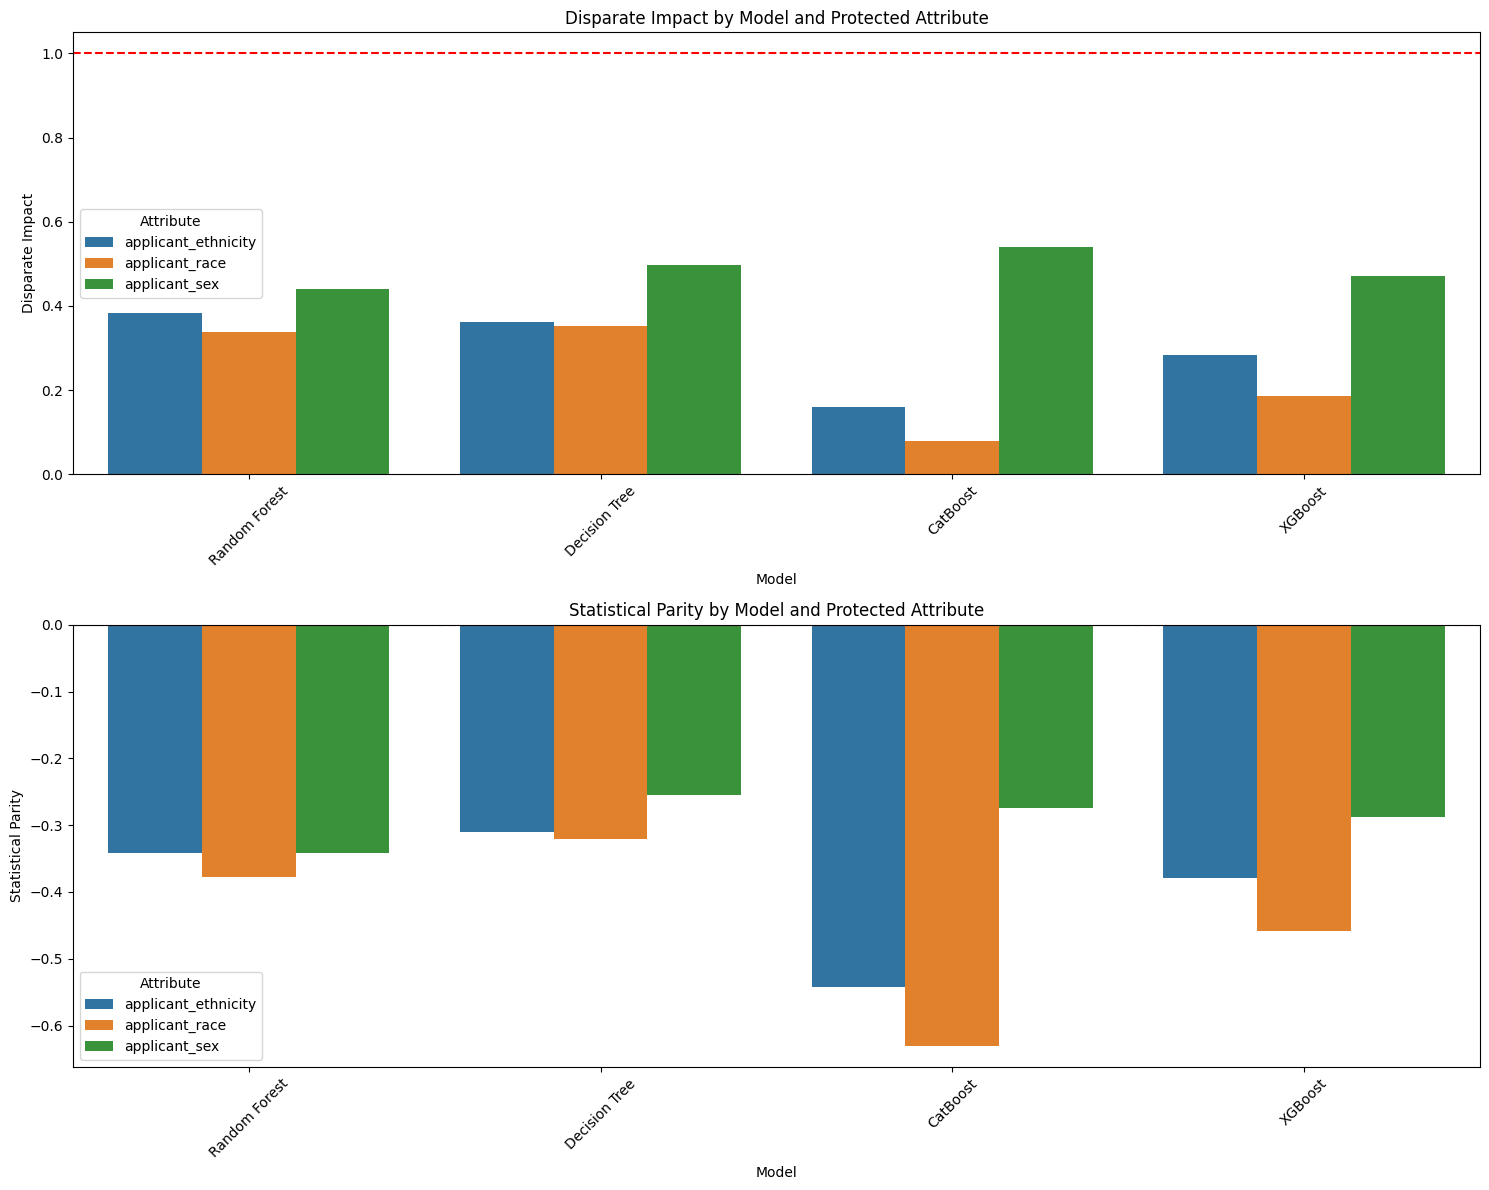


Detailed Fairness Metrics for All Models:

Random Forest:

applicant_ethnicity-1:
Disparate Impact: 0.383
Statistical Parity: -0.342

applicant_race-1:
Disparate Impact: 0.339
Statistical Parity: -0.378

applicant_sex:
Disparate Impact: 0.439
Statistical Parity: -0.342

Decision Tree:

applicant_ethnicity-1:
Disparate Impact: 0.362
Statistical Parity: -0.310

applicant_race-1:
Disparate Impact: 0.352
Statistical Parity: -0.320

applicant_sex:
Disparate Impact: 0.498
Statistical Parity: -0.255

CatBoost:

applicant_ethnicity-1:
Disparate Impact: 0.160
Statistical Parity: -0.542

applicant_race-1:
Disparate Impact: 0.080
Statistical Parity: -0.630

applicant_sex:
Disparate Impact: 0.541
Statistical Parity: -0.275

XGBoost:

applicant_ethnicity-1:
Disparate Impact: 0.284
Statistical Parity: -0.379

applicant_race-1:
Disparate Impact: 0.185
Statistical Parity: -0.459

applicant_sex:
Disparate Impact: 0.472
Statistical Parity: -0.288

LIME Explanations for Random Forest:


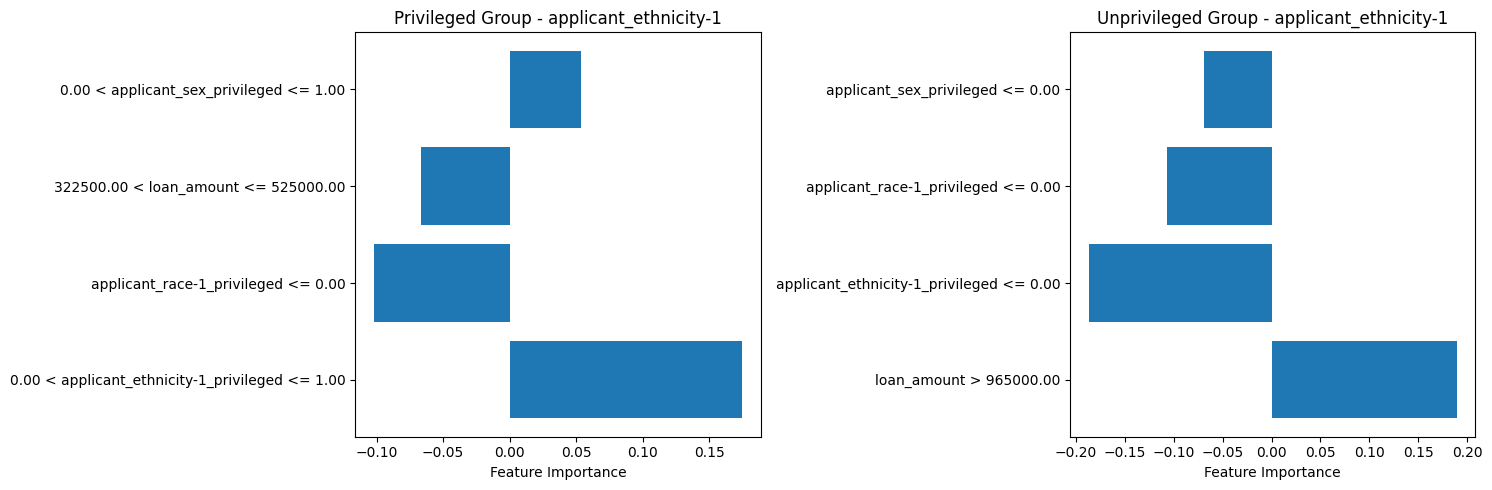


applicant_ethnicity-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1748
applicant_race-1_privileged <= 0.00: -0.1020
322500.00 < loan_amount <= 525000.00: -0.0669
0.00 < applicant_sex_privileged <= 1.00: 0.0533

Unprivileged Group Explanation:
loan_amount > 965000.00: 0.1895
applicant_ethnicity-1_privileged <= 0.00: -0.1873
applicant_race-1_privileged <= 0.00: -0.1073
applicant_sex_privileged <= 0.00: -0.0692


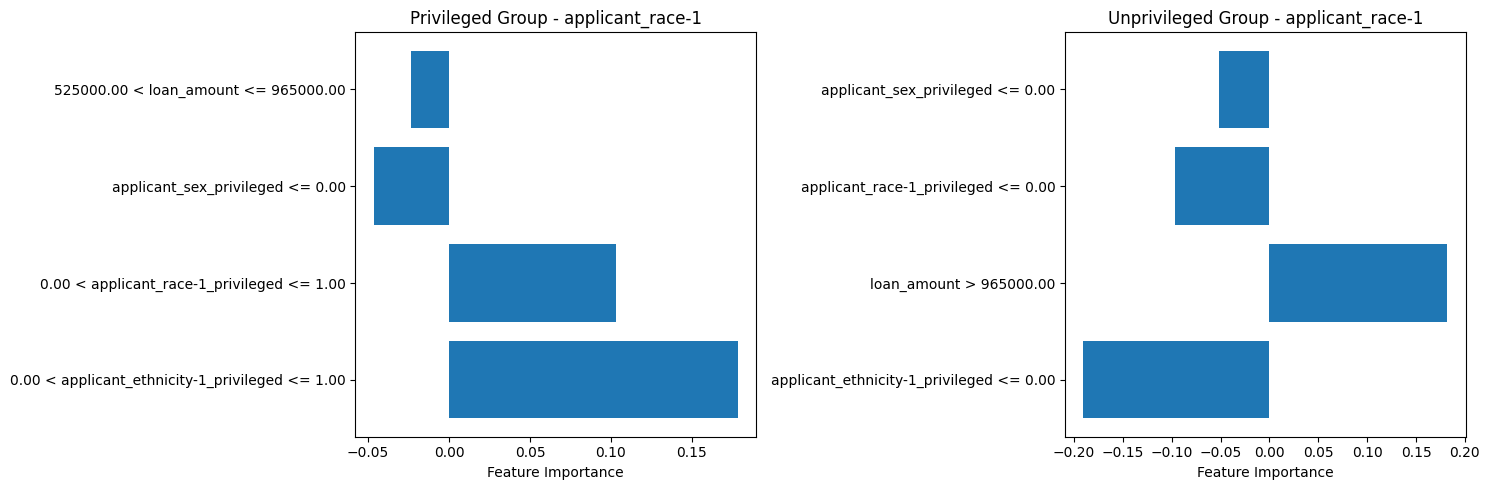


applicant_race-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1783
0.00 < applicant_race-1_privileged <= 1.00: 0.1034
applicant_sex_privileged <= 0.00: -0.0466
525000.00 < loan_amount <= 965000.00: -0.0238

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.1902
loan_amount > 965000.00: 0.1821
applicant_race-1_privileged <= 0.00: -0.0970
applicant_sex_privileged <= 0.00: -0.0517


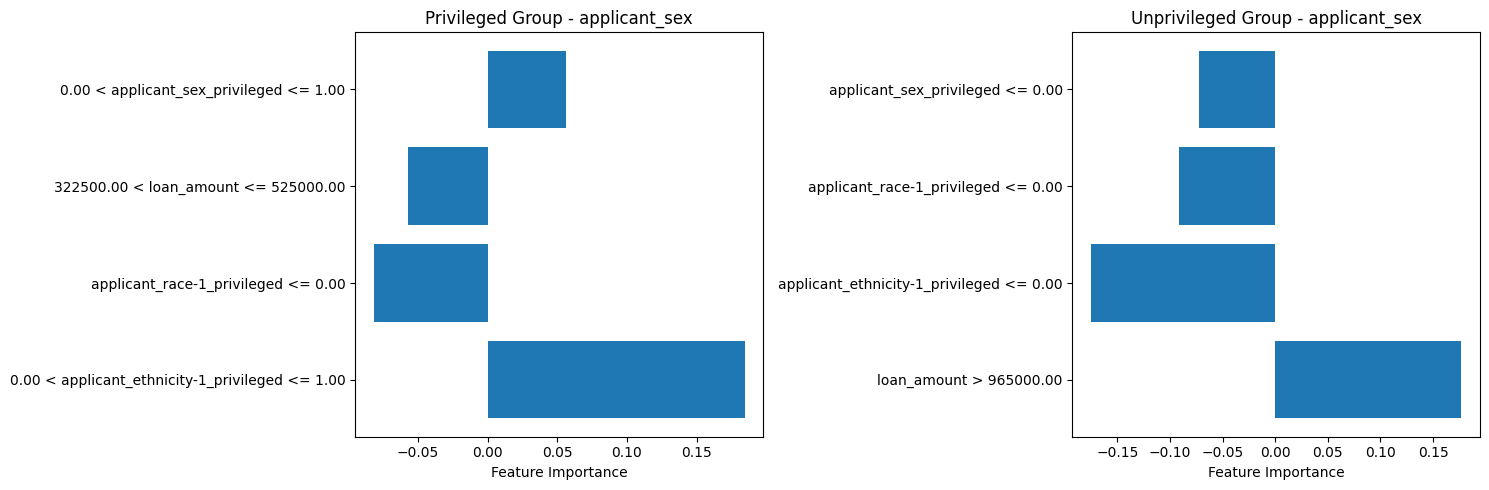


applicant_sex:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1843
applicant_race-1_privileged <= 0.00: -0.0815
322500.00 < loan_amount <= 525000.00: -0.0571
0.00 < applicant_sex_privileged <= 1.00: 0.0562

Unprivileged Group Explanation:
loan_amount > 965000.00: 0.1771
applicant_ethnicity-1_privileged <= 0.00: -0.1751
applicant_race-1_privileged <= 0.00: -0.0915
applicant_sex_privileged <= 0.00: -0.0723

LIME Explanations for Decision Tree:


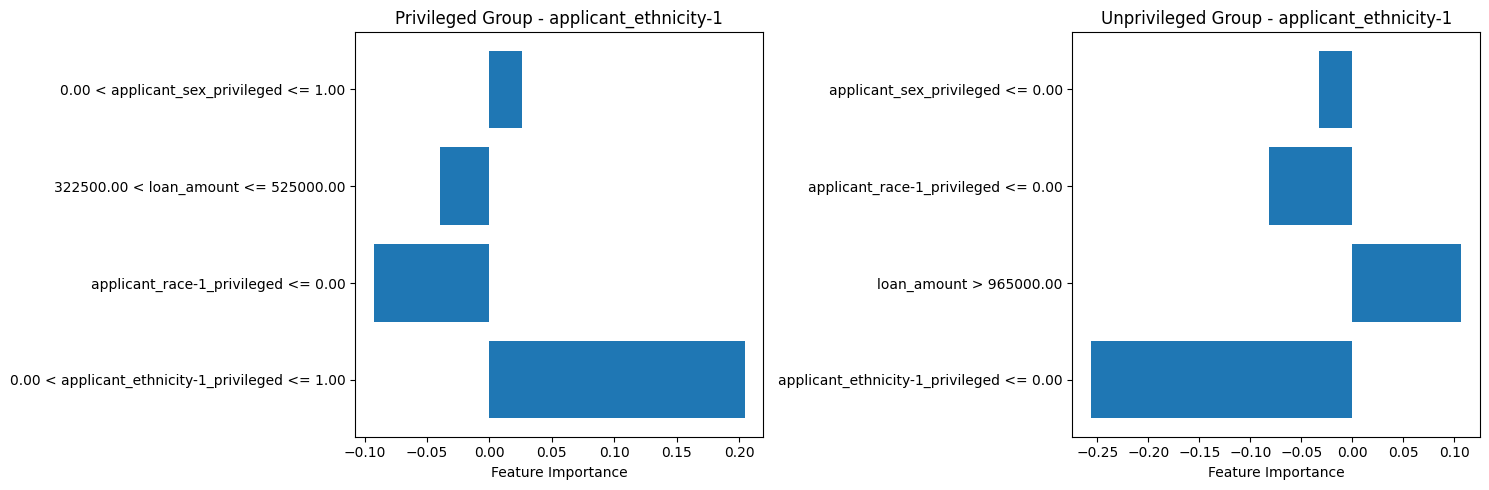


applicant_ethnicity-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.2045
applicant_race-1_privileged <= 0.00: -0.0925
322500.00 < loan_amount <= 525000.00: -0.0397
0.00 < applicant_sex_privileged <= 1.00: 0.0260

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.2564
loan_amount > 965000.00: 0.1073
applicant_race-1_privileged <= 0.00: -0.0818
applicant_sex_privileged <= 0.00: -0.0323


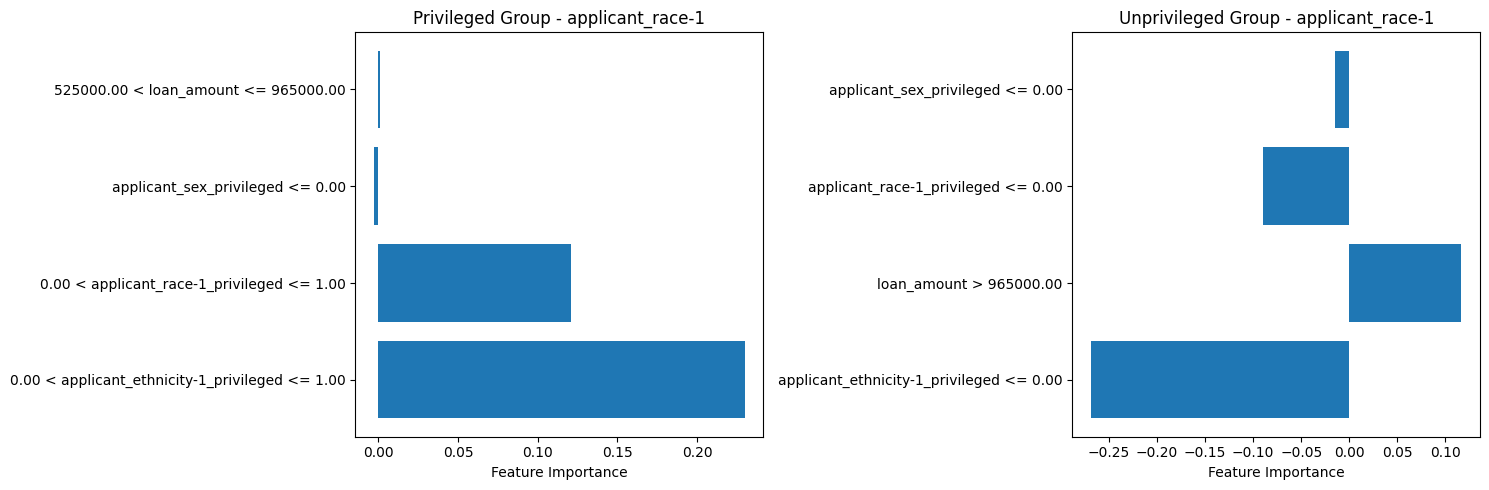


applicant_race-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.2297
0.00 < applicant_race-1_privileged <= 1.00: 0.1205
applicant_sex_privileged <= 0.00: -0.0028
525000.00 < loan_amount <= 965000.00: 0.0008

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.2688
loan_amount > 965000.00: 0.1168
applicant_race-1_privileged <= 0.00: -0.0897
applicant_sex_privileged <= 0.00: -0.0144


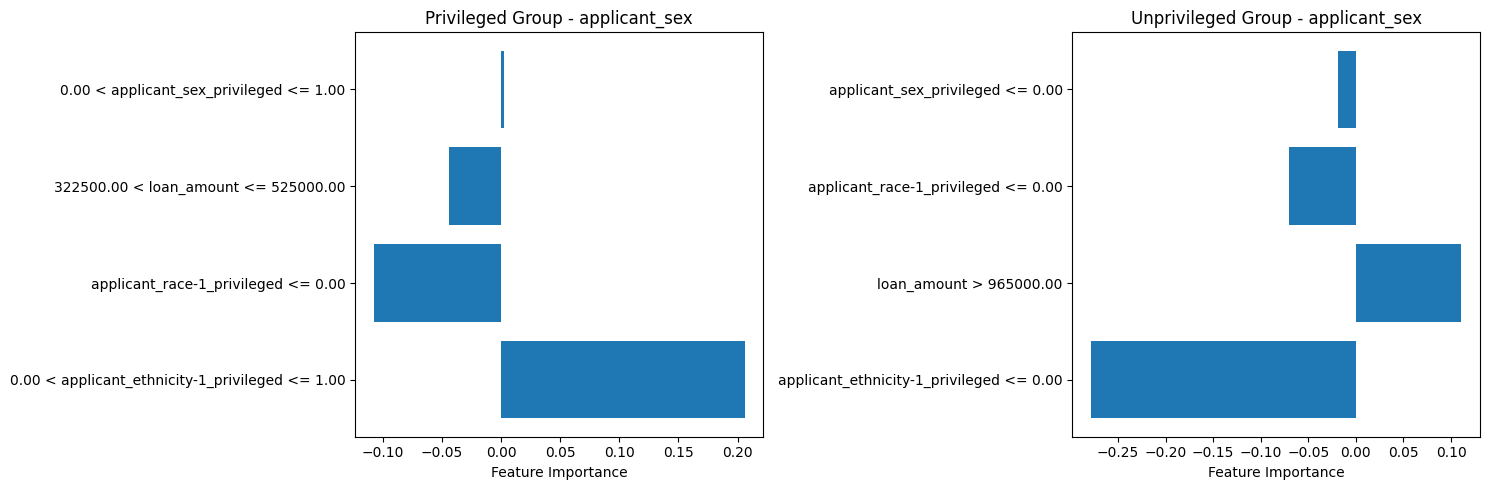


applicant_sex:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.2058
applicant_race-1_privileged <= 0.00: -0.1074
322500.00 < loan_amount <= 525000.00: -0.0438
0.00 < applicant_sex_privileged <= 1.00: 0.0025

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.2785
loan_amount > 965000.00: 0.1109
applicant_race-1_privileged <= 0.00: -0.0702
applicant_sex_privileged <= 0.00: -0.0184

LIME Explanations for CatBoost:


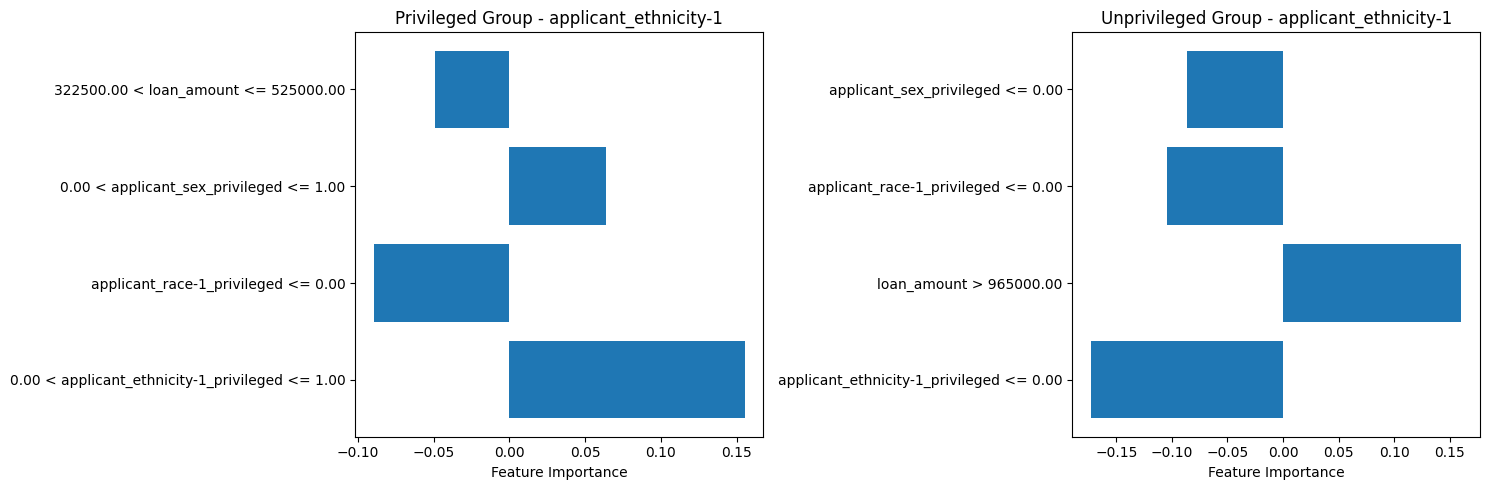


applicant_ethnicity-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1553
applicant_race-1_privileged <= 0.00: -0.0893
0.00 < applicant_sex_privileged <= 1.00: 0.0638
322500.00 < loan_amount <= 525000.00: -0.0489

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.1730
loan_amount > 965000.00: 0.1607
applicant_race-1_privileged <= 0.00: -0.1041
applicant_sex_privileged <= 0.00: -0.0868


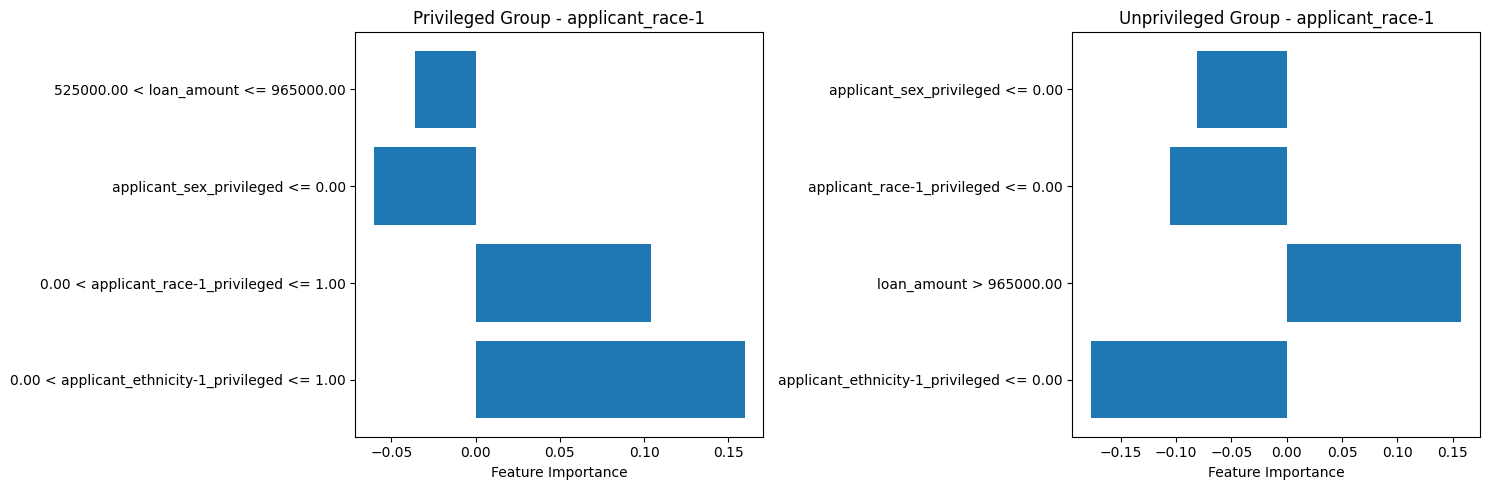


applicant_race-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1596
0.00 < applicant_race-1_privileged <= 1.00: 0.1038
applicant_sex_privileged <= 0.00: -0.0603
525000.00 < loan_amount <= 965000.00: -0.0360

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.1768
loan_amount > 965000.00: 0.1579
applicant_race-1_privileged <= 0.00: -0.1054
applicant_sex_privileged <= 0.00: -0.0807


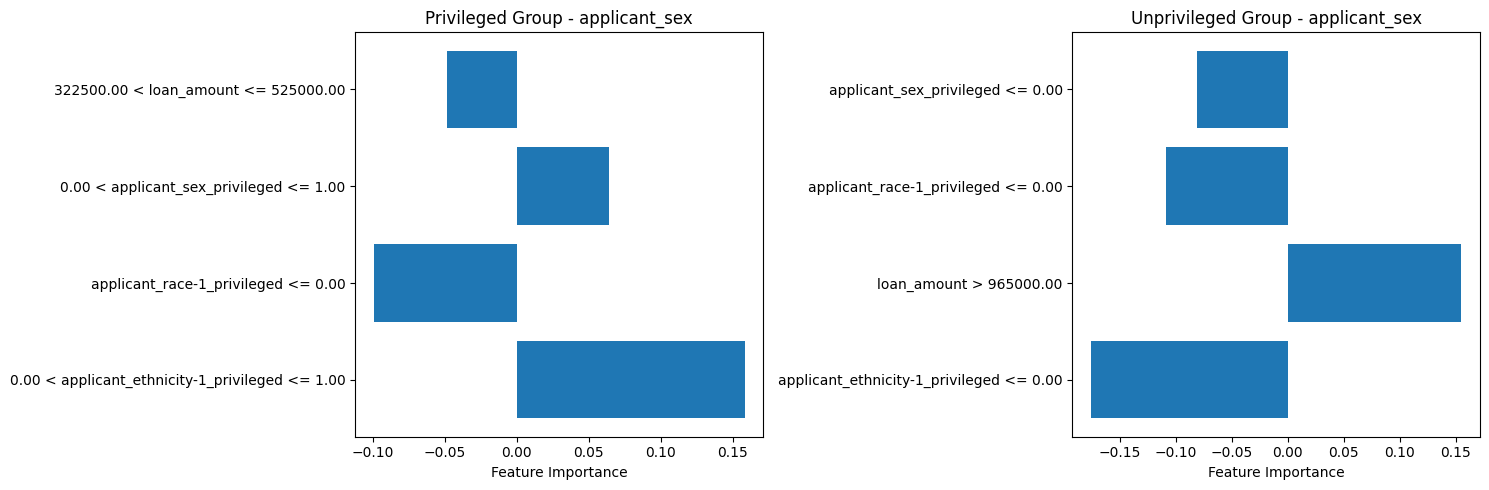


applicant_sex:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1583
applicant_race-1_privileged <= 0.00: -0.0991
0.00 < applicant_sex_privileged <= 1.00: 0.0641
322500.00 < loan_amount <= 525000.00: -0.0486

Unprivileged Group Explanation:
applicant_ethnicity-1_privileged <= 0.00: -0.1761
loan_amount > 965000.00: 0.1553
applicant_race-1_privileged <= 0.00: -0.1088
applicant_sex_privileged <= 0.00: -0.0815

LIME Explanations for XGBoost:


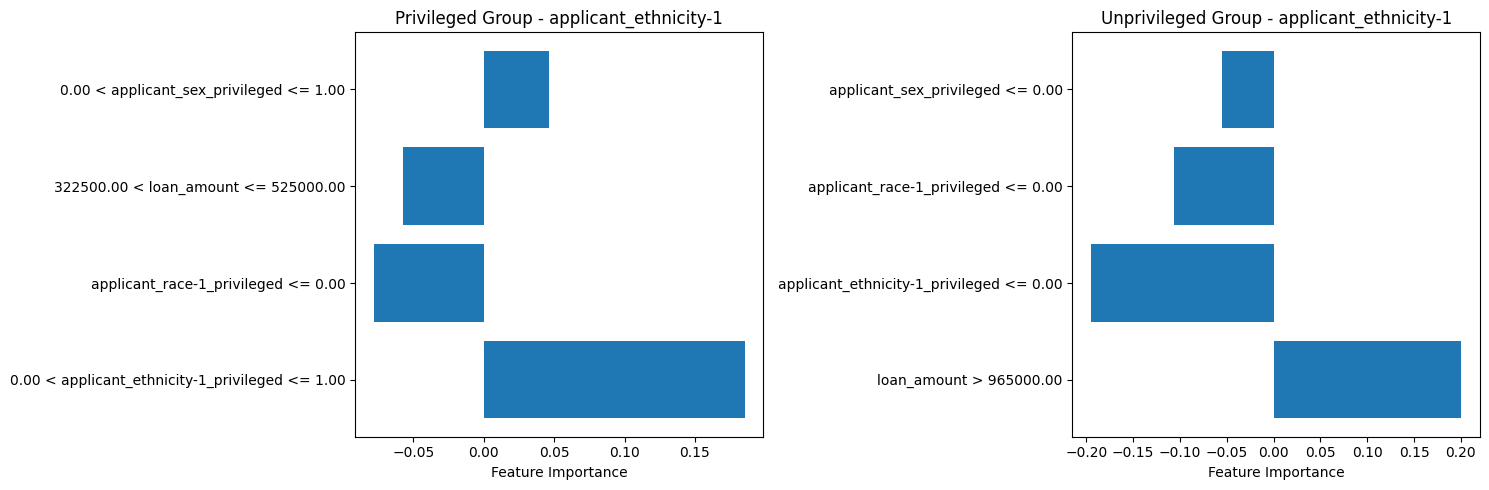


applicant_ethnicity-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1852
applicant_race-1_privileged <= 0.00: -0.0778
322500.00 < loan_amount <= 525000.00: -0.0569
0.00 < applicant_sex_privileged <= 1.00: 0.0465

Unprivileged Group Explanation:
loan_amount > 965000.00: 0.2006
applicant_ethnicity-1_privileged <= 0.00: -0.1951
applicant_race-1_privileged <= 0.00: -0.1059
applicant_sex_privileged <= 0.00: -0.0552


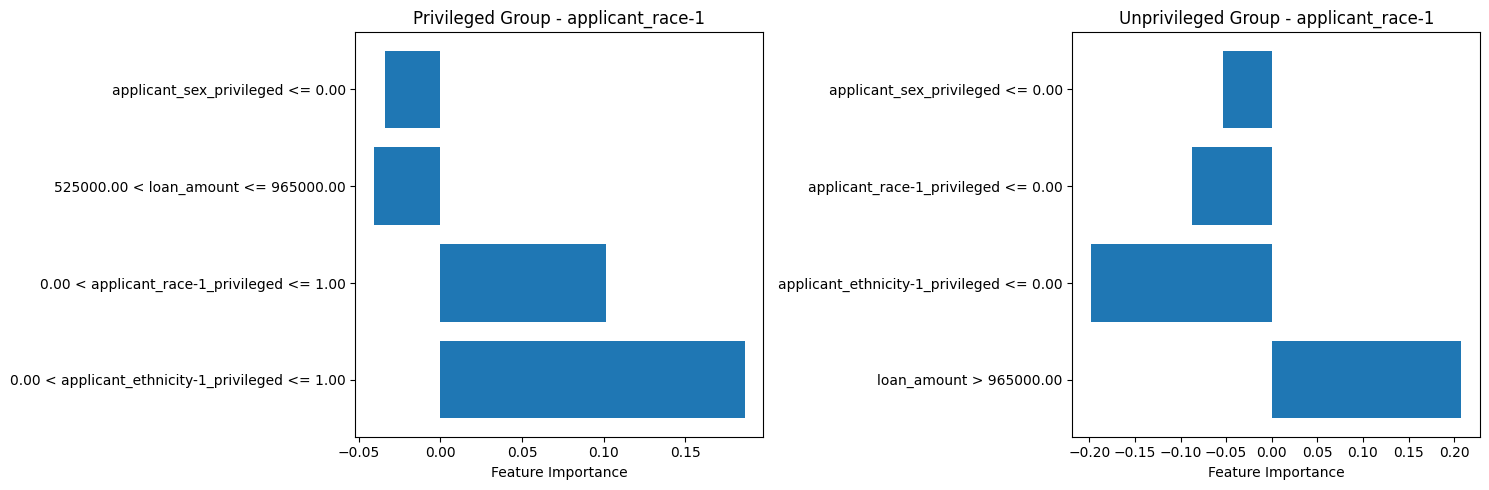


applicant_race-1:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1863
0.00 < applicant_race-1_privileged <= 1.00: 0.1015
525000.00 < loan_amount <= 965000.00: -0.0407
applicant_sex_privileged <= 0.00: -0.0337

Unprivileged Group Explanation:
loan_amount > 965000.00: 0.2080
applicant_ethnicity-1_privileged <= 0.00: -0.1982
applicant_race-1_privileged <= 0.00: -0.0877
applicant_sex_privileged <= 0.00: -0.0534


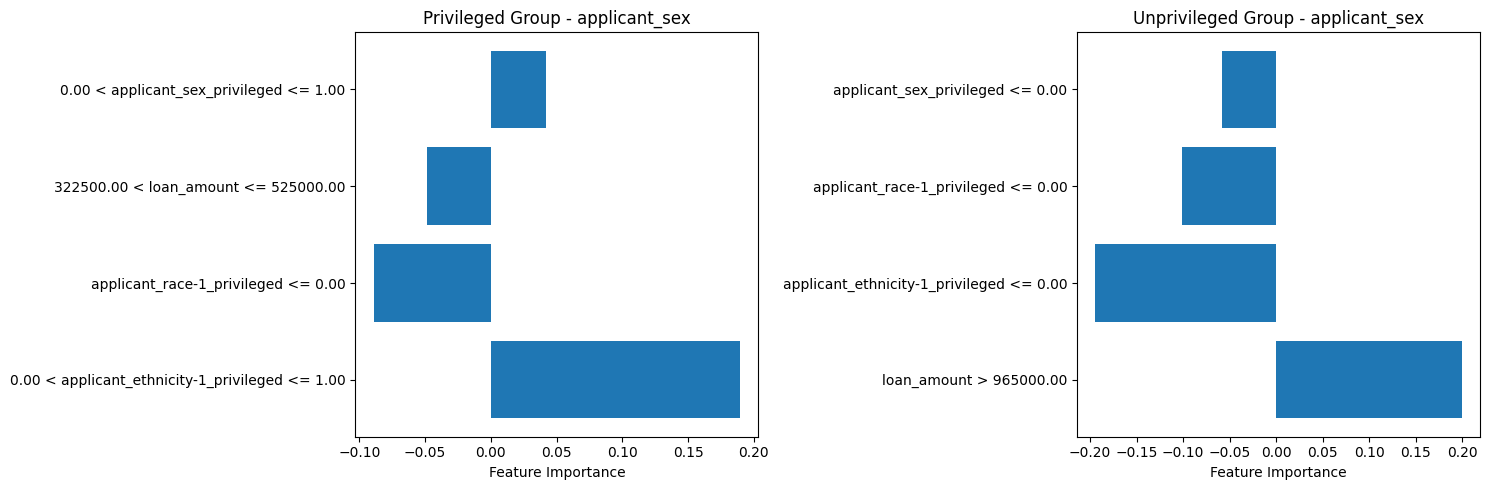


applicant_sex:

Privileged Group Explanation:
0.00 < applicant_ethnicity-1_privileged <= 1.00: 0.1896
applicant_race-1_privileged <= 0.00: -0.0890
322500.00 < loan_amount <= 525000.00: -0.0489
0.00 < applicant_sex_privileged <= 1.00: 0.0417

Unprivileged Group Explanation:
loan_amount > 965000.00: 0.1995
applicant_ethnicity-1_privileged <= 0.00: -0.1943
applicant_race-1_privileged <= 0.00: -0.1015
applicant_sex_privileged <= 0.00: -0.0581


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lime
import lime.lime_tabular

class MultiModelFairnessAnalyzer:
    def __init__(self, data_path):
        self.data = pd.read_csv(data_path)
        self.protected_attributes = ['applicant_ethnicity-1', 'applicant_race-1', 'applicant_sex']
        self.models = {
            'Random Forest': make_pipeline(
                SimpleImputer(strategy='median'),
                StandardScaler(),
                RandomForestClassifier(n_estimators=100, random_state=42)
            ),
            'Decision Tree': make_pipeline(
                SimpleImputer(strategy='median'),
                StandardScaler(),
                DecisionTreeClassifier(random_state=42)
            ),
            'CatBoost': make_pipeline(
                SimpleImputer(strategy='median'),
                StandardScaler(),
                CatBoostClassifier(verbose=0, random_seed=42)
            ),
            'XGBoost': make_pipeline(
                SimpleImputer(strategy='median'),
                StandardScaler(),
                xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
            )
        }

    def calculate_fairness_metrics(self, y_pred, protected_attributes):
        """Calculate fairness metrics"""
        y_pred = np.array(y_pred)
        protected_attributes = np.array(protected_attributes)

        # Calculate disparate impact
        unpriv_mask = (protected_attributes == 0)
        priv_mask = (protected_attributes == 1)

        if not any(priv_mask) or not any(unpriv_mask):
            return {'disparate_impact': np.nan, 'statistical_parity': np.nan}

        unpriv_pos = np.mean(y_pred[unpriv_mask])
        priv_pos = np.mean(y_pred[priv_mask])

        disparate_impact = unpriv_pos / priv_pos if priv_pos > 0 else np.nan
        statistical_parity = unpriv_pos - priv_pos

        return {
            'disparate_impact': disparate_impact,
            'statistical_parity': statistical_parity
        }

    def preprocess_data(self):
        """Preprocess the data"""
        # Create binary outcome
        self.data['action_taken'] = (self.data['action_taken'] == 1).astype(int)

        # Create binary encodings for protected attributes
        for attr in self.protected_attributes:
            self.data[attr] = self.data[attr].astype(str)

            if attr == 'applicant_ethnicity-1':
                self.data[f'{attr}_privileged'] = (self.data[attr] == '2').astype(int)
            elif attr == 'applicant_race-1':
                self.data[f'{attr}_privileged'] = (self.data[attr] == '5').astype(int)
            elif attr == 'applicant_sex':
                self.data[f'{attr}_privileged'] = (self.data[attr] == '1').astype(int)

        # Select features
        numeric_features = ['loan_amount']
        privilege_features = [f'{attr}_privileged' for attr in self.protected_attributes]
        self.features = numeric_features + privilege_features

        # Prepare X and y
        X = self.data[self.features].copy()
        y = self.data['action_taken']

        return train_test_split(X, y, test_size=0.2, random_state=42)

    # def generate_lime_explanations(self, model, X_train, X_test, model_name):
    #     """Generate LIME explanations for each protected attribute"""
    #     explainer = lime.lime_tabular.LimeTabularExplainer(
    #         X_train.values,
    #         feature_names=X_train.columns,
    #         class_names=['Denied', 'Approved'],
    #         mode='classification'
    #     )

    #     lime_explanations = {}

    #     for attr in self.protected_attributes:
    #         priv_mask = X_test[f'{attr}_privileged'] == 1
    #         unpriv_mask = X_test[f'{attr}_privileged'] == 0

    #         priv_example = X_test[priv_mask].iloc[0] if any(priv_mask) else None
    #         unpriv_example = X_test[unpriv_mask].iloc[0] if any(unpriv_mask) else None

    #         explanations = {
    #             'privileged': explainer.explain_instance(
    #                 priv_example.values,
    #                 model.predict_proba,
    #                 num_features=len(self.features)
    #             ) if priv_example is not None else None,

    #             'unprivileged': explainer.explain_instance(
    #                 unpriv_example.values,
    #                 model.predict_proba,
    #                 num_features=len(self.features)
    #             ) if unpriv_example is not None else None
    #         }

    #         lime_explanations[attr] = explanations

    #     return lime_explanations

    def visualize_model_results(self, all_results):
        """Visualize fairness metrics for all models"""
        # Prepare data for visualization
        plot_data = []
        for model_name, results in all_results.items():
            for attr in self.protected_attributes:
                metrics = results['fairness_metrics'][attr]
                plot_data.append({
                    'Model': model_name,
                    'Attribute': attr.replace('-1', ''),
                    'Disparate Impact': metrics['disparate_impact'],
                    'Statistical Parity': metrics['statistical_parity']
                })

        plot_df = pd.DataFrame(plot_data)

        # Create subplots for each metric
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

        # Plot Disparate Impact
        sns.barplot(data=plot_df, x='Model', y='Disparate Impact', hue='Attribute', ax=ax1)
        ax1.set_title('Disparate Impact by Model and Protected Attribute')
        ax1.axhline(y=1.0, color='r', linestyle='--', label='Equal Impact')
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

        # Plot Statistical Parity
        sns.barplot(data=plot_df, x='Model', y='Statistical Parity', hue='Attribute', ax=ax2)
        ax2.set_title('Statistical Parity by Model and Protected Attribute')
        ax2.axhline(y=0.0, color='r', linestyle='--', label='Equal Parity')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

        plt.tight_layout()
        plt.show()

        # Print detailed metrics
        print("\nDetailed Fairness Metrics for All Models:")
        for model_name, results in all_results.items():
            print(f"\n{model_name}:")
            for attr in self.protected_attributes:
                metrics = results['fairness_metrics'][attr]
                print(f"\n{attr}:")
                print(f"Disparate Impact: {metrics['disparate_impact']:.3f}")
                print(f"Statistical Parity: {metrics['statistical_parity']:.3f}")


    def visualize_lime_explanations(self, lime_explanations, model_name):
        """Visualize LIME explanations for a specific model"""
        print(f"\nLIME Explanations for {model_name}:")

        for attr in self.protected_attributes:
            explanations = lime_explanations[attr]

            # Create figure for plotting
            plt.figure(figsize=(15, 5))

            # Plot for privileged group
            plt.subplot(1, 2, 1)
            if explanations['privileged'] is not None:
                # Get explanation data
                exp_list = explanations['privileged'].as_list()
                features, values = zip(*exp_list)

                # Create horizontal bar plot
                y_pos = np.arange(len(features))
                plt.barh(y_pos, values)
                plt.yticks(y_pos, features)
                plt.title(f'Privileged Group - {attr}')
                plt.xlabel('Feature Importance')
            else:
                plt.text(0.5, 0.5, 'No privileged examples found',
                        horizontalalignment='center')

            # Plot for unprivileged group
            plt.subplot(1, 2, 2)
            if explanations['unprivileged'] is not None:
                # Get explanation data
                exp_list = explanations['unprivileged'].as_list()
                features, values = zip(*exp_list)

                # Create horizontal bar plot
                y_pos = np.arange(len(features))
                plt.barh(y_pos, values)
                plt.yticks(y_pos, features)
                plt.title(f'Unprivileged Group - {attr}')
                plt.xlabel('Feature Importance')
            else:
                plt.text(0.5, 0.5, 'No unprivileged examples found',
                        horizontalalignment='center')

            plt.tight_layout()
            plt.show()

            # Print detailed explanation
            print(f"\n{attr}:")
            print("\nPrivileged Group Explanation:")
            if explanations['privileged'] is not None:
                for feature, importance in explanations['privileged'].as_list():
                    print(f"{feature}: {importance:.4f}")

            print("\nUnprivileged Group Explanation:")
            if explanations['unprivileged'] is not None:
                for feature, importance in explanations['unprivileged'].as_list():
                    print(f"{feature}: {importance:.4f}")

    def generate_lime_explanations(self, model, X_train, X_test, model_name):
        """Generate LIME explanations for each protected attribute"""
        explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train.values,
            feature_names=X_train.columns,
            class_names=['Denied', 'Approved'],
            mode='classification'
        )

        lime_explanations = {}

        for attr in self.protected_attributes:
            priv_mask = X_test[f'{attr}_privileged'] == 1
            unpriv_mask = X_test[f'{attr}_privileged'] == 0

            try:
                priv_example = X_test[priv_mask].iloc[0] if any(priv_mask) else None
                unpriv_example = X_test[unpriv_mask].iloc[0] if any(unpriv_mask) else None

                explanations = {
                    'privileged': explainer.explain_instance(
                        priv_example.values,
                        model.predict_proba,
                        num_features=len(self.features)
                    ) if priv_example is not None else None,

                    'unprivileged': explainer.explain_instance(
                        unpriv_example.values,
                        model.predict_proba,
                        num_features=len(self.features)
                    ) if unpriv_example is not None else None
                }

            except Exception as e:
                print(f"Error generating LIME explanation for {model_name}, {attr}: {str(e)}")
                explanations = {'privileged': None, 'unprivileged': None}

            lime_explanations[attr] = explanations

        return lime_explanations

    def run_analysis(self):
        """Run the complete analysis for all models"""
        X_train, X_test, y_train, y_test = self.preprocess_data()

        all_results = {}

        for model_name, model in self.models.items():
            print(f"\nTraining {model_name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Calculate fairness metrics
            fairness_results = {}
            for attr in self.protected_attributes:
                fairness_results[attr] = self.calculate_fairness_metrics(
                    y_pred, X_test[f'{attr}_privileged'])

            # Generate LIME explanations
            lime_explanations = self.generate_lime_explanations(model, X_train, X_test, model_name)

            all_results[model_name] = {
                'model': model,
                'predictions': y_pred,
                'fairness_metrics': fairness_results,
                'lime_explanations': lime_explanations
            }

        # Visualize results
        self.visualize_model_results(all_results)

        # Visualize LIME explanations for each model
        for model_name, results in all_results.items():
            self.visualize_lime_explanations(results['lime_explanations'], model_name)

        return all_results

# Run the analysis
analyzer = MultiModelFairnessAnalyzer("state_CO_lei_7H6GLXDRUGQFU57RNE97.csv")
results = analyzer.run_analysis()

The analysis conducted examines the fairness and explainability of four machine learning models—Random Forest, Decision Tree, CatBoost, and XGBoost—on a dataset involving loan applicants. The fairness of each model is evaluated based on two key metrics: Disparate Impact and Statistical Parity, which assess whether the model treats different protected groups (such as ethnicity, race, and sex) equally. The results show varied fairness performance across models:

Random Forest and Decision Tree models display relatively low disparate impact and negative statistical parity across most protected attributes, indicating that these models tend to disadvantage certain groups, particularly in the applicant's ethnicity and race.
CatBoost shows the most significant disparity, especially with applicant ethnicity and race, where disparate impact values are notably low, pointing to a strong bias against these groups.
XGBoost exhibits moderate fairness, with some improvements over Random Forest and Decision Tree, but still shows negative statistical parity, particularly for race and ethnicity groups.
LIME (Local Interpretable Model-agnostic Explanations) was used to provide model interpretability, revealing that for both privileged and unprivileged groups, the feature importance remains distinct, with loan amount being a dominant factor across the board. The privileged group (typically benefiting from attributes like ethnicity or sex) often saw positive feature importance for those attributes, while the unprivileged group faced negative associations with them. This reflects potential biases in decision-making processes that the models may have learned from the data.

Overall, these insights suggest that while machine learning models provide predictive power, they may propagate existing biases in societal attributes such as ethnicity, race, and sex. Disparate impact and statistical parity metrics highlight the need for further model refinement to ensure fairness, especially in sensitive applications like loan approval

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 2248, number of used features: 4
[LightGBM] [Info] Start training from score -0.845668
[LightGBM] [Info] Start training from score -4.673274
[LightGBM] [Info] Start training from score -2.922006
[LightGBM] [Info] Start training from score -2.212465
[LightGBM] [Info] Start training from score -3.217987
[LightGBM] [Info] Start training from score -1.026954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

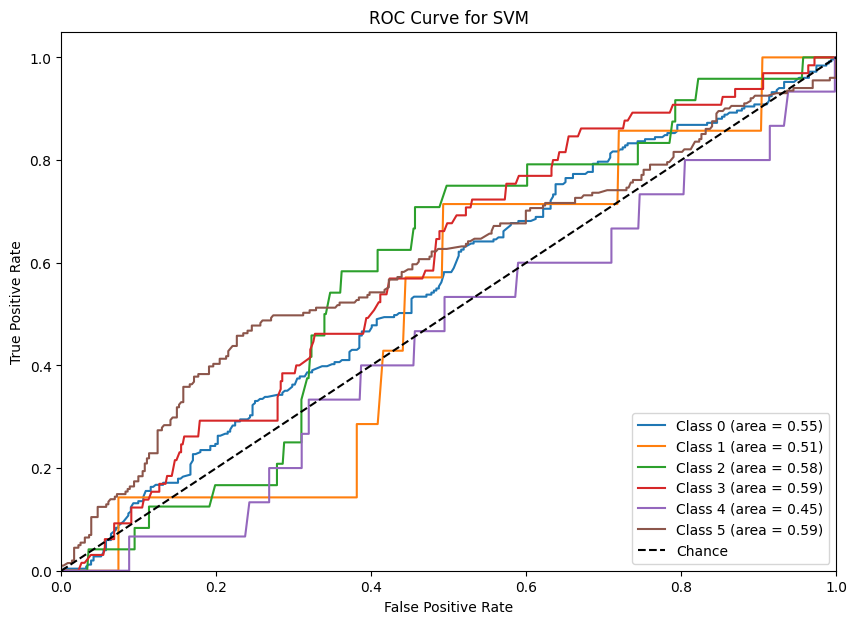

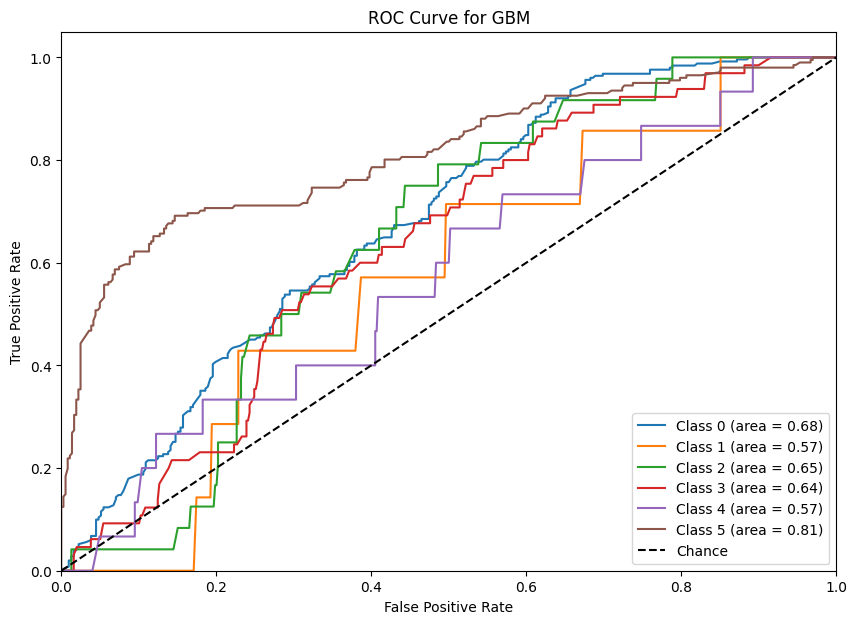

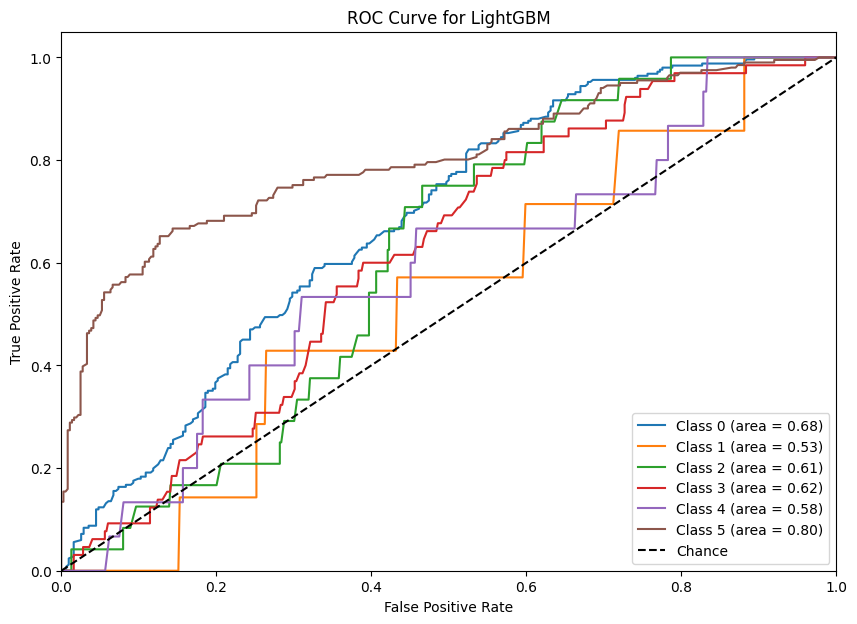

In [16]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the output for multi-class ROC curve calculation
classes = np.unique(y_train)
y_test_binarized = label_binarize(y_test, classes=classes)

# SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_probs = svm_model.predict_proba(X_test)

# Gradient Boosting
gbm_model = GradientBoostingClassifier(random_state=42)
gbm_model.fit(X_train, y_train)
gbm_preds = gbm_model.predict(X_test)
gbm_probs = gbm_model.predict_proba(X_test)

# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)

# Plot ROC curves for each model
for model_name, probs in zip(
    ["SVM", "GBM", "LightGBM"],
    [svm_probs, gbm_probs, lgb_probs]
):
    fpr = {}
    tpr = {}
    roc_auc = {}

    # Compute ROC curve and ROC area for each class
    for i, class_label in enumerate(classes):
        fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:, i], probs[:, i])
        roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

    # Plot each class's ROC curve
    plt.figure(figsize=(10, 7))
    for class_label in classes:
        plt.plot(
            fpr[class_label],
            tpr[class_label],
            label=f"Class {class_label} (area = {roc_auc[class_label]:.2f})"
        )

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve for {model_name}")
    plt.legend(loc="lower right")
    plt.show()

Here we train three machine learning models **SVM**, **Gradient Boosting**, and **LightGBM** and evaluate them using ROC curves. The SVM model is trained with probability estimates to generate class predictions and compute ROC curves. However, SVMs are sensitive to feature scaling and may face challenges with noisy data. The Gradient Boosting model iteratively boosts weak learners, but it generates warnings indicating possible convergence issues or feature interaction problems. LightGBM, optimized for large datasets, shows warnings about a lack of positive gains during training, which may suggest overfitting or insufficient data diversity, though it still produces output. The ROC curves for each model plot the True Positive Rate against the False Positive Rate, with the Area Under the Curve (AUC) providing a measure of classification performance. Higher AUC values indicate better model discrimination, while values closer to 0.5 suggest poor performance. Each model’s class-specific performance can be compared based on AUC scores, which reveal how well they distinguish between classes. The warnings in LightGBM suggest the model may require hyperparameter tuning or feature engineering adjustments. Comparing the AUC scores of all models can help determine which one handles the multi-class classification task most effectively.

In [17]:
# Collect Metrics
for model_name, preds, probs in zip(
    ["SVM", "GBM", "LightGBM"],
    [svm_preds, gbm_preds, lgb_preds],
    [svm_probs, gbm_probs, lgb_probs]
):
    print(f"\nPerformance Metrics for {model_name}:")
    print(classification_report(y_test, preds))
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, probs, multi_class='ovr'):.4f}")



Performance Metrics for SVM:
              precision    recall  f1-score   support

           0       0.47      0.86      0.61       251
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        24
           3       0.00      0.00      0.00        65
           4       0.00      0.00      0.00        15
           5       0.55      0.27      0.37       201

    accuracy                           0.48       563
   macro avg       0.17      0.19      0.16       563
weighted avg       0.41      0.48      0.40       563

Accuracy: 0.4831
ROC AUC: 0.5467

Performance Metrics for GBM:
              precision    recall  f1-score   support

           0       0.56      0.90      0.69       251
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        24
           3       0.00      0.00      0.00        65
           4       0.00      0.00      0.00        15
           5       0.79      0.59      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

The performance of the three models SVM, Gradient Boosting (GBM), and LightGBM reveals several important insights about their ability to classify the dataset. The SVM model exhibits a high recall for class 0 (0.86), indicating it is effective at identifying instances of this class, but struggles with the other classes, particularly classes 1, 2, 3, and 4, where recall is zero. This results in low F1-scores for these classes, reflecting poor balance between precision and recall. The model’s accuracy is 0.4831, and its ROC AUC score of 0.5467 is relatively low, indicating that it lacks discriminatory power. The Gradient Boosting model shows improvement with an accuracy of 0.6110 and an AUC of 0.6531. It performs well for class 0 (precision 0.56, recall 0.90) and class 5 (precision 0.79, recall 0.59), but still faces challenges with the minority classes, where recall remains zero for several of them. The LightGBM model, with an accuracy of 0.5915 and an AUC of 0.6371, shows similar performance to GBM, excelling with class 0 and class 5 but underperforming with other classes. Overall, the class imbalance is evident across all models, as seen in the poor precision and recall for minority classes, suggesting a need for techniques like class weighting or resampling. While GBM outperforms the other models in terms of accuracy and ROC AUC, all models display limited performance for the minority classes, highlighting room for improvement through hyperparameter tuning, feature engineering, and addressing class imbalance.








/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:57:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
<ipython-input-18-362cb3d0fc7a>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")


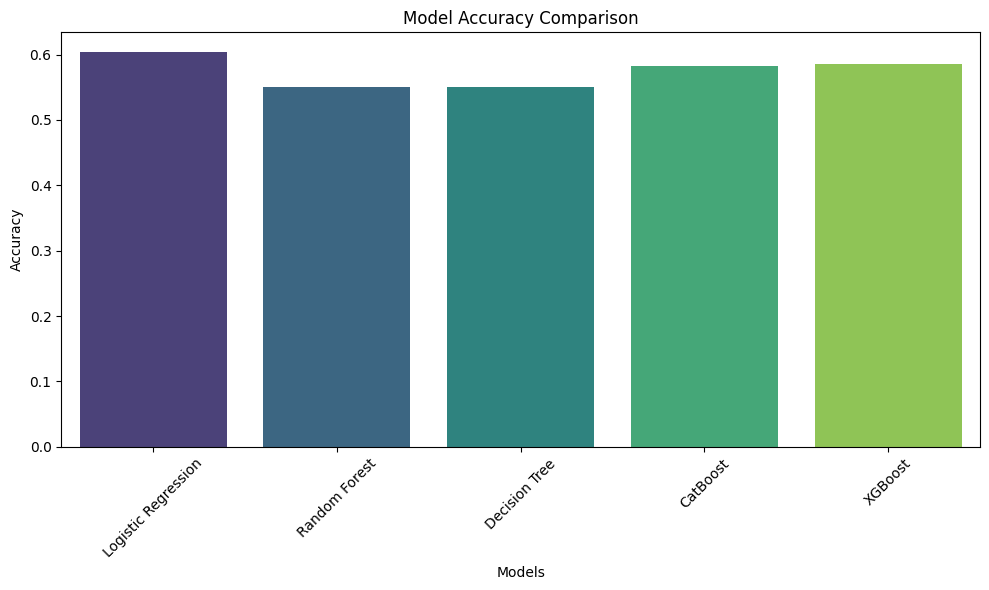

In [18]:
from sklearn.metrics import accuracy_score

# Dictionary to store accuracies
model_accuracies = {}

# Evaluate each model and store accuracy
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc

# Plot the accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model Accuracy Comparison Analysis shows the performance evaluation of five different machine learning models used for classification. Logistic Regression emerges as the top performer with approximately 0.60 (60%) accuracy, suggesting that the relationship between features and target variable has a strong linear component. Its superior performance indicates that complex nonlinear relationships may not be crucial for this particular problem. XGBoost and CatBoost algorithms show similar performance levels, achieving around 0.58 (58%) accuracy, slightly lower than Logistic Regression, indicating that ensemble methods don't provide significant advantages for this dataset. Random Forest and Decision Tree models show the lowest performance at approximately 0.55 (55%) accuracy, and their similar performance suggests that ensemble of trees doesn't significantly improve prediction capability. The relatively small performance gap (only 5%) between the best and worst models suggests that the prediction task is challenging, while the superior performance of Logistic Regression indicates that a simple linear approach might be most appropriate for this dataset. Notably, more complex ensemble methods (XGBoost, CatBoost, Random Forest) don't provide significant advantages despite their typically superior performance on many problems, which could indicate that the underlying patterns in the data are predominantly linear in nature.

In [19]:
from sklearn.model_selection import GridSearchCV

# Fine-tuning Random Forest
rf_params = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    'randomforestclassifier__min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        RandomForestClassifier(random_state=42)
    ),
    param_grid=rf_params,
    cv=3,
    scoring='accuracy',
    verbose=1
)

rf_grid.fit(X_train, y_train)
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Random Forest Parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 100}



we have used  GridSearchCV to fine-tune the hyperparameters of a Random Forest model. The (rf_params) dictionary specifies a range of potential values for three hyperparameters of the RandomForestClassifier: the number of trees, the maximum depth of the trees, and the minimum number of samples required to split an internal node.

The GridSearchCV is set up with a pipeline that first applies SimpleImputer to handle any missing values using the median strategy, followed by a StandardScaler for feature scaling, and then the RandomForestClassifier. The grid search performs a 3-fold cross-validation, evaluates models based on accuracy, and prints the progress of the search due to the verbose=1 parameter. After fitting the grid search to the training data , it identifies the best hyperparameter combination based on cross-validation performance

This process ensures that the best combination of hyperparameters is selected, optimizing the Random Forest model's performance and improving the model’s accuracy on unseen data.

Fine-Tuned Random Forest Accuracy: 0.6003552397868561


<ipython-input-20-a124429a5682>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")


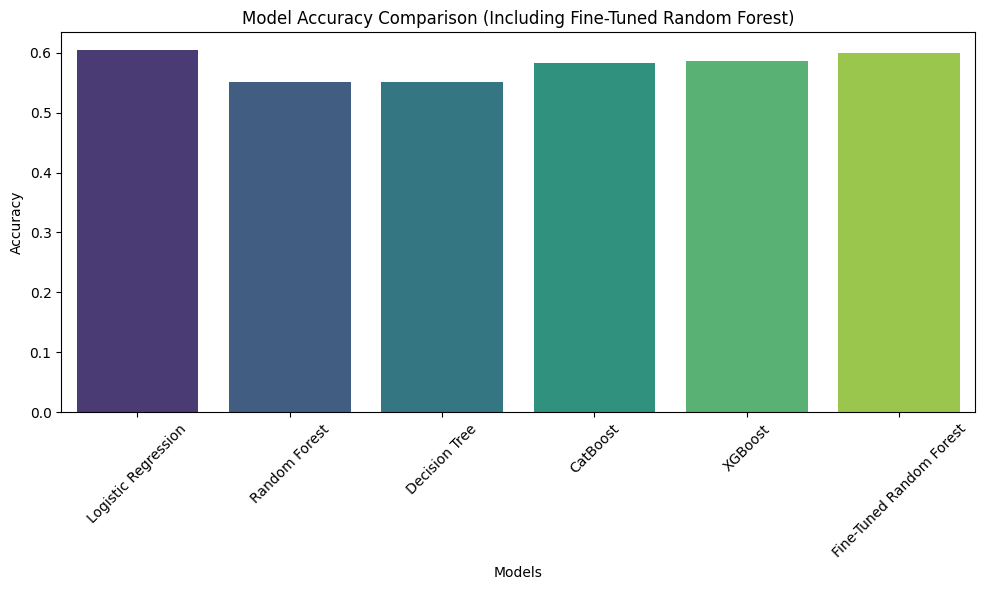

In [20]:
# Retrieve the best model from the grid search
best_rf_model = rf_grid.best_estimator_

# Train and test the fine-tuned model
best_rf_model.fit(X_train, y_train)
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Compute accuracy
fine_tuned_rf_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Fine-Tuned Random Forest Accuracy: {fine_tuned_rf_accuracy}")

# Update accuracy dictionary
model_accuracies['Fine-Tuned Random Forest'] = fine_tuned_rf_accuracy

# Updated bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")
plt.title("Model Accuracy Comparison (Including Fine-Tuned Random Forest)")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:58:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:58:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:58:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:58:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [01:58:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


XGBoost (Fine-Tuned) Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.94      0.69       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        15
           6       0.84      0.51      0.64       201

    accuracy                           0.60       563
   macro avg       0.23      0.24      0.22       563
weighted avg       0.54      0.60      0.53       563



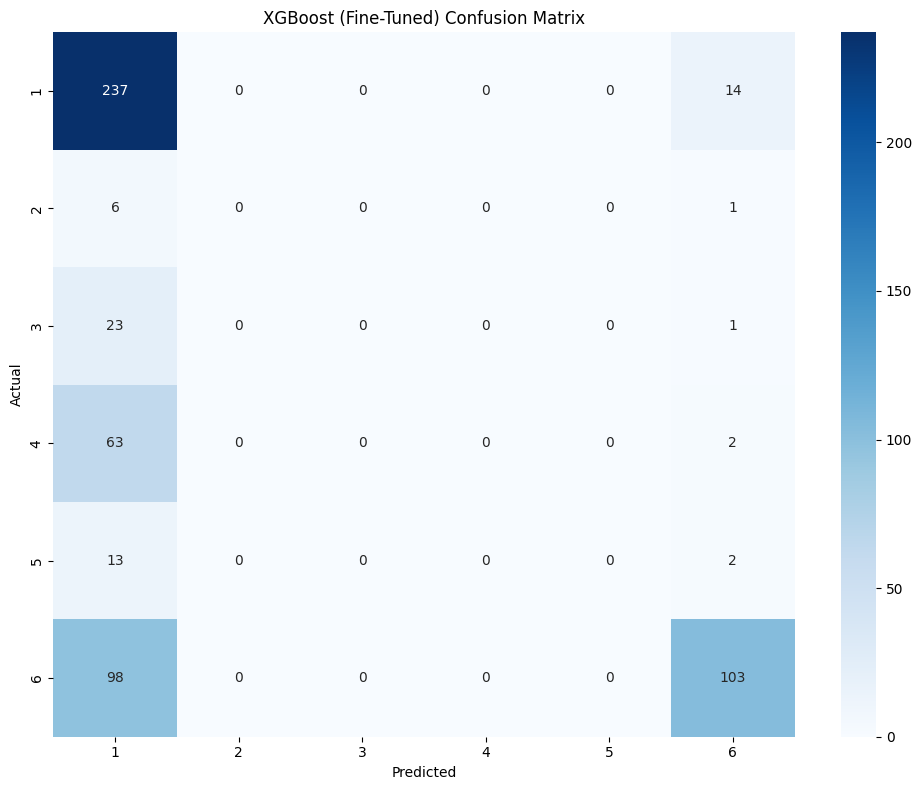


XGBoost (Fine-Tuned) LIME Explanations:
Prediction error: 'randomforestclassifier'
LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.model_selection import GridSearchCV

# Fine-tune XGBoost
xgb_param_grid = {
    'xgbclassifier__n_estimators': [50, 100, 150],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
}

xgb_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
)

xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, scoring='accuracy', cv=3, verbose=1)
xgb_grid.fit(X_train, y_train)

# Evaluate the fine-tuned model
evaluate_model(
    xgb_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost (Fine-Tuned)",
    label_encoder
)

The XGBoost model's classification report and confusion matrix reveal a complex performance pattern with an overall accuracy of 60%. The model shows strong performance for Class 1 (precision=0.54, recall=0.94, f1-score=0.69) and Class 6 (precision=0.84, recall=0.51, f1-score=0.64), but completely fails to predict Classes 2,3,4,5 (all metrics at 0.00). The confusion matrix highlights that the model essentially functions as a binary classifier between Classes 1 and 6, with 237 correct predictions for Class 1 and 103 correct predictions for Class 6. Most misclassifications occur between these two dominant classes, with 14 samples from Class 1 being incorrectly classified as Class 6 and 98 samples from Class 6 being misclassified as Class 1. The poor performance on Classes 2(7 samples), 3(24 samples), 4(65 samples), and 5(15 samples) indicates a significant class imbalance issue, as all samples from these minority classes are being misclassified into either Class 1 or Class 6. The weighted averages (precision=0.54, recall=0.60, f1-score=0.53) reflect this imbalanced performance across classes, suggesting the need for techniques like SMOTE or class weights to improve prediction for minority classes.

Fitting 3 folds for each of 27 candidates, totalling 81 fits

CatBoost (Fine-Tuned) Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.92      0.69       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        15
           6       0.81      0.55      0.66       201

    accuracy                           0.61       563
   macro avg       0.23      0.25      0.22       563
weighted avg       0.53      0.61      0.54       563



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


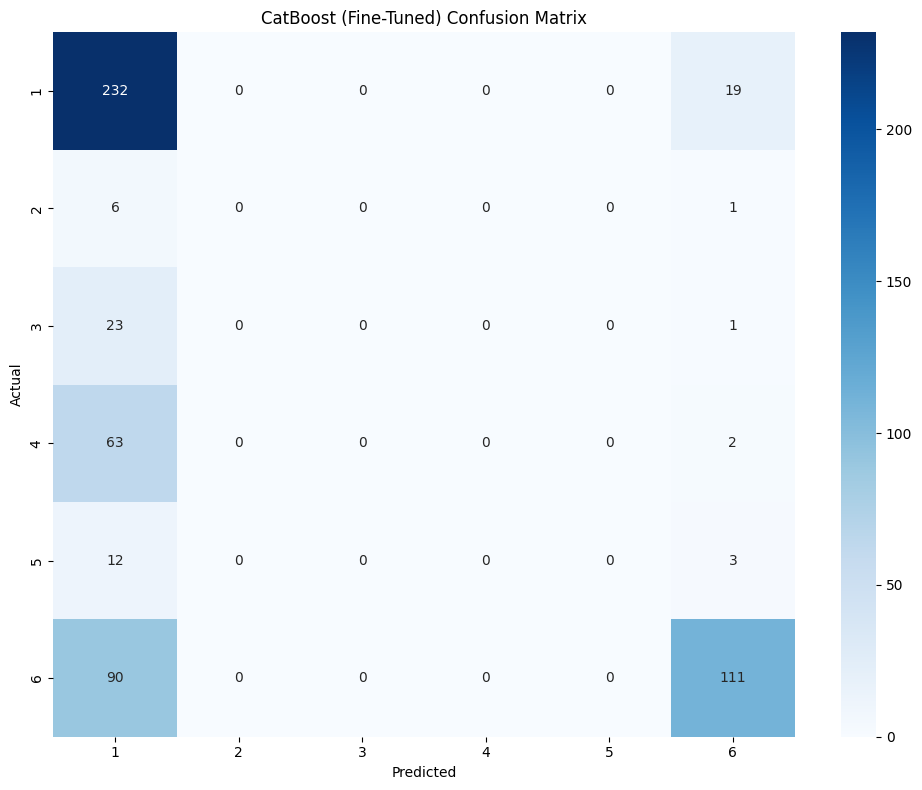


CatBoost (Fine-Tuned) LIME Explanations:
Prediction error: 'randomforestclassifier'
LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [22]:
# Fine-tune CatBoost
catboost_param_grid = {
    'catboostclassifier__iterations': [100, 200, 300],
    'catboostclassifier__depth': [4, 6, 8],
    'catboostclassifier__learning_rate': [0.01, 0.1, 0.2],
}

catboost_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    CatBoostClassifier(verbose=0, random_seed=42)
)

catboost_grid = GridSearchCV(catboost_model, catboost_param_grid, scoring='accuracy', cv=3, verbose=1)
catboost_grid.fit(X_train, y_train)

# Evaluate the fine-tuned model
evaluate_model(
    catboost_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    "CatBoost (Fine-Tuned)",
    label_encoder
)


The CatBoost fine-tuned model's classification report and confusion matrix show an overall accuracy of 61%, slightly better than the XGBoost model. The model demonstrates strong performance on Class 1 (precision=0.54, recall=0.92, f1-score=0.69 with 251 samples) and Class 6 (precision=0.81, recall=0.55, f1-score=0.66 with 201 samples). However, like XGBoost, it completely fails to predict Classes 2,3,4,5 (all showing 0.00 for precision, recall, and f1-score), which are minority classes with few samples (7, 24, 65, and 15 samples respectively). The confusion matrix reveals that the model primarily predicts between Classes 1 and 6, with 232 correct predictions for Class 1 and 111 correct predictions for Class 6. The misclassification pattern shows 19 samples from Class 1 incorrectly classified as Class 6 and 90 samples from Class 6 misclassified as Class 1. The weighted averages (precision=0.53, recall=0.61, f1-score=0.54) and macro averages (precision=0.23, recall=0.25, f1-score=0.22) reflect the model's imbalanced performance across classes. The model was fitted using 3 folds for each of 27 candidates, totaling 81 fits during the fine-tuning process, suggesting extensive hyperparameter optimization was performed.

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Decision Tree (Fine-Tuned) Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.94      0.69       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        65
           5       0.00      0.00      0.00        15
           6       0.84      0.51      0.64       201

    accuracy                           0.60       563
   macro avg       0.23      0.24      0.22       563
weighted avg       0.54      0.60      0.53       563



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


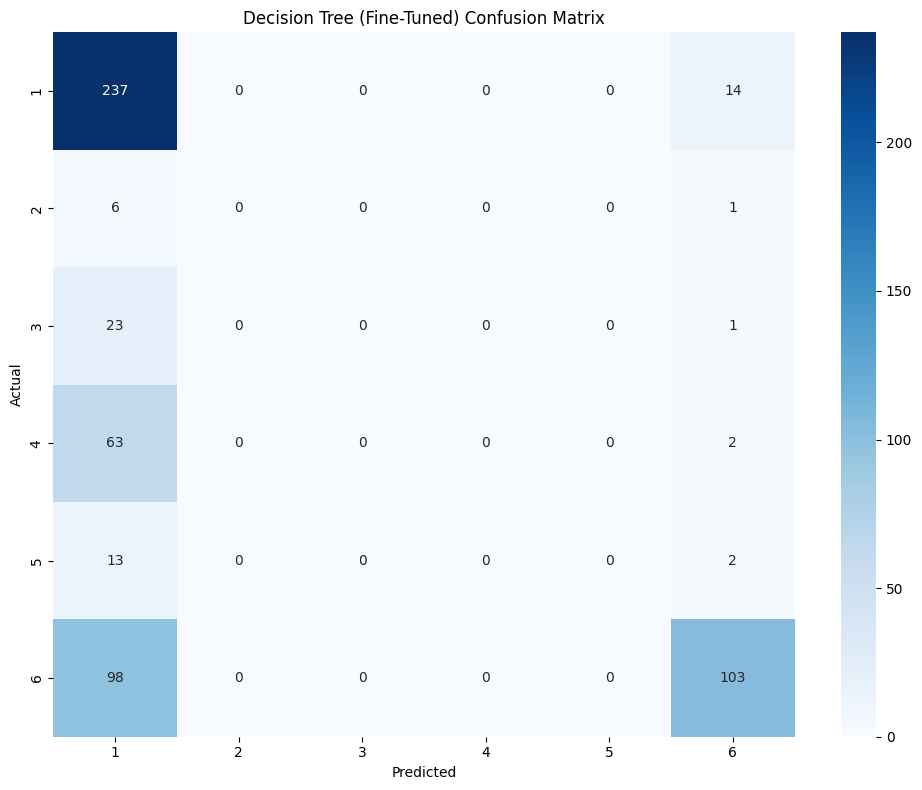


Decision Tree (Fine-Tuned) LIME Explanations:
Prediction error: 'randomforestclassifier'
LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [23]:
# Fine-tune Decision Tree
dt_param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 4],
}

dt_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    DecisionTreeClassifier(random_state=42)
)

dt_grid = GridSearchCV(dt_model, dt_param_grid, scoring='accuracy', cv=3, verbose=1)
dt_grid.fit(X_train, y_train)

# Evaluate the fine-tuned model
evaluate_model(
    dt_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree (Fine-Tuned)",
    label_encoder
)


The fine-tuned Decision Tree model shows mixed performance, with strong results for class 1, where it has a high precision (0.54), recall (0.94), and F1-score (0.69). However, it struggles with other classes, particularly class 2, 3, and 4, where it achieves near-zero precision, recall, and F1-scores, indicating significant misclassification. Class 6 shows a better performance, with a precision of 0.84 and a recall of 0.51, but still has some misclassifications. Overall, the model achieves an accuracy of 0.60, with a macro average score of 0.23 for precision, 0.24 for recall, and 0.22 for F1, highlighting its poor performance across most classes. The weighted average is better, with scores of 0.54 for precision, 0.60 for recall, and 0.53 for F1, reflecting the model's tendency to perform better on more frequent classes, particularly class 1 and 6. This suggests that while the model performs reasonably well on certain classes, it fails to effectively distinguish between others, resulting in an imbalanced overall performance.

<ipython-input-24-92fed64dd59d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='Accuracy', palette='viridis')


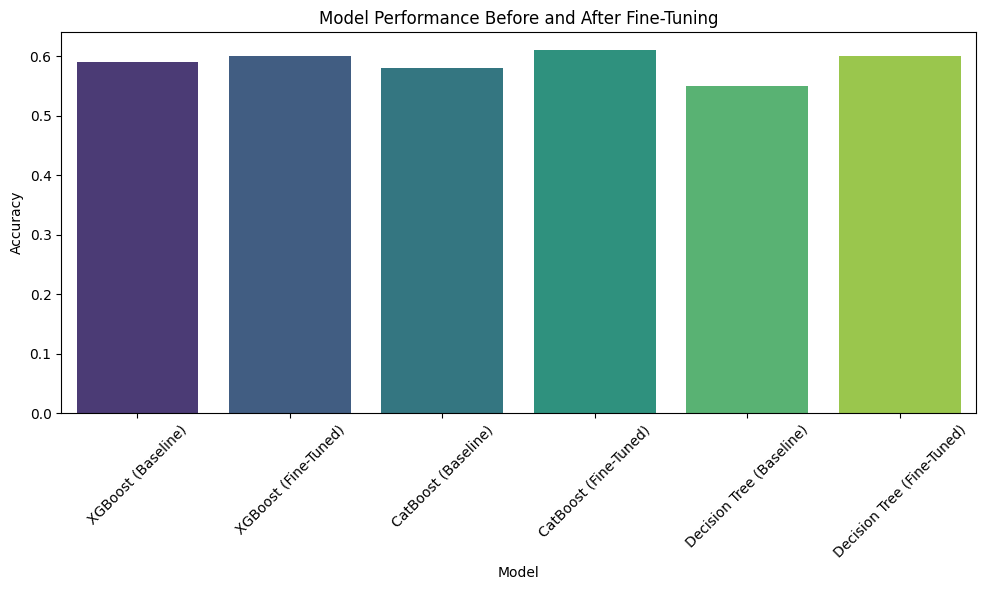

In [24]:
# Collect performance metrics
performance_metrics = {
    'Model': [
        'XGBoost (Baseline)', 'XGBoost (Fine-Tuned)',
        'CatBoost (Baseline)', 'CatBoost (Fine-Tuned)',
        'Decision Tree (Baseline)', 'Decision Tree (Fine-Tuned)'
    ],
    'Accuracy': [0.59, 0.60, 0.58, 0.61, 0.55, 0.60]
}

# Create DataFrame for visualization
performance_df = pd.DataFrame(performance_metrics)

# Plot bar graph
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Performance Before and After Fine-Tuning')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart displays the performance of different models (XGBoost, CatBoost, and Decision Tree) before and after fine-tuning, measured by accuracy
Across all three models, fine-tuning results in a noticeable improvement in accuracy compared to the baseline.
This suggests that the fine-tuning process effectively optimized the models for the given task.
he relative improvement from baseline to fine-tuned is consistent across the models.
Fine-tuned XGBoost and CatBoost achieve higher accuracy compared to the Decision Tree, indicating that ensemble methods (like boosting) are more effective for this task.
Both XGBoost and CatBoost exhibit similar baseline and fine-tuned performances, suggesting they are equally capable on this dataset.
While fine-tuning improves the Decision Tree's accuracy, its baseline and fine-tuned performances are lower than the boosting models.
This indicates that Decision Trees may struggle with the dataset's complexity compared to ensemble methods.
Fine-tuning is crucial for extracting the best performance from models, especially boosting algorithms like XGBoost and CatBoost.
Ensemble methods outperform single-tree models, aligning with their ability to reduce bias and variance.

Fitting 3 folds for each of 8 candidates, totalling 24 fits

kNN (Fine-Tuned) Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.80      0.65       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.20      0.08      0.11        65
           5       0.00      0.00      0.00        15
           6       0.69      0.57      0.62       201

    accuracy                           0.57       563
   macro avg       0.24      0.24      0.23       563
weighted avg       0.51      0.57      0.53       563



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


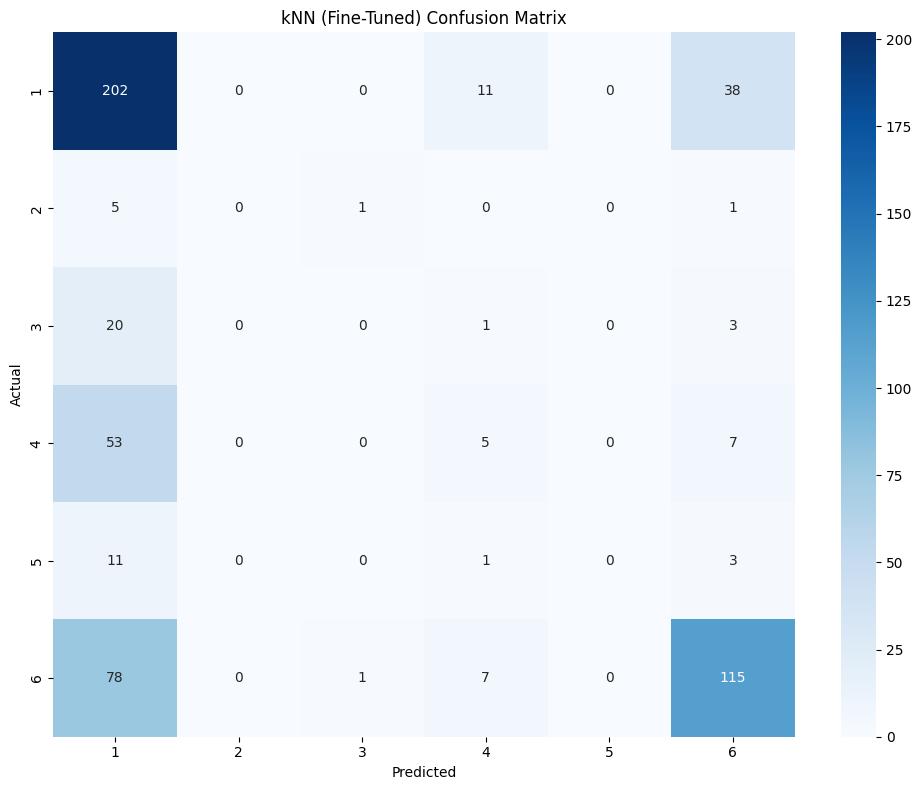


kNN (Fine-Tuned) LIME Explanations:
Prediction error: 'randomforestclassifier'


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


LIME Explanation Error: 1


In [25]:
from sklearn.neighbors import KNeighborsClassifier

# Fine-tune kNN
knn_param_grid = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9],
    'kneighborsclassifier__weights': ['uniform', 'distance']
}

knn_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    KNeighborsClassifier()
)

knn_grid = GridSearchCV(knn_model, knn_param_grid, scoring='accuracy', cv=3, verbose=1)
knn_grid.fit(X_train, y_train)

# Evaluate the fine-tuned model
evaluate_model(
    knn_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    "kNN (Fine-Tuned)",
    label_encoder
)

The fine-tuned kNN classifier shows moderate overall performance with 57% accuracy and a weighted average F1-score of 0.53, indicating significant room for improvement. The model performs best on Classes 1 and 6, which are the largest classes (251 and 201 samples respectively), with Class 1 achieving 80% recall and 55% precision, while Class 6 shows 69% precision and 57% recall. However, the model struggles significantly with Classes 2, 3, and 5, showing zero precision and recall due to severe class imbalance (having only 7, 24, and 15 samples respectively). The confusion matrix reveals a strong bias towards predicting Classes 1 and 6, with most samples from minority classes being misclassified into these categories. Class 4 also performs poorly with only 5 correct predictions out of 65 samples, resulting in a very low recall of 0.08. To improve the model, it would be beneficial to address the class imbalance through techniques like oversampling, undersampling, or class weights, collect more data for underrepresented classes, consider feature engineering, and experiment with different k values or alternative algorithms better suited for imbalanced datasets.

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Naive Bayes (Fine-Tuned) Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.68      0.61       251
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        24
           4       0.20      0.32      0.25        65
           5       0.25      0.07      0.11        15
           6       0.78      0.54      0.64       201

    accuracy                           0.53       563
   macro avg       0.30      0.27      0.27       563
weighted avg       0.55      0.53      0.53       563



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


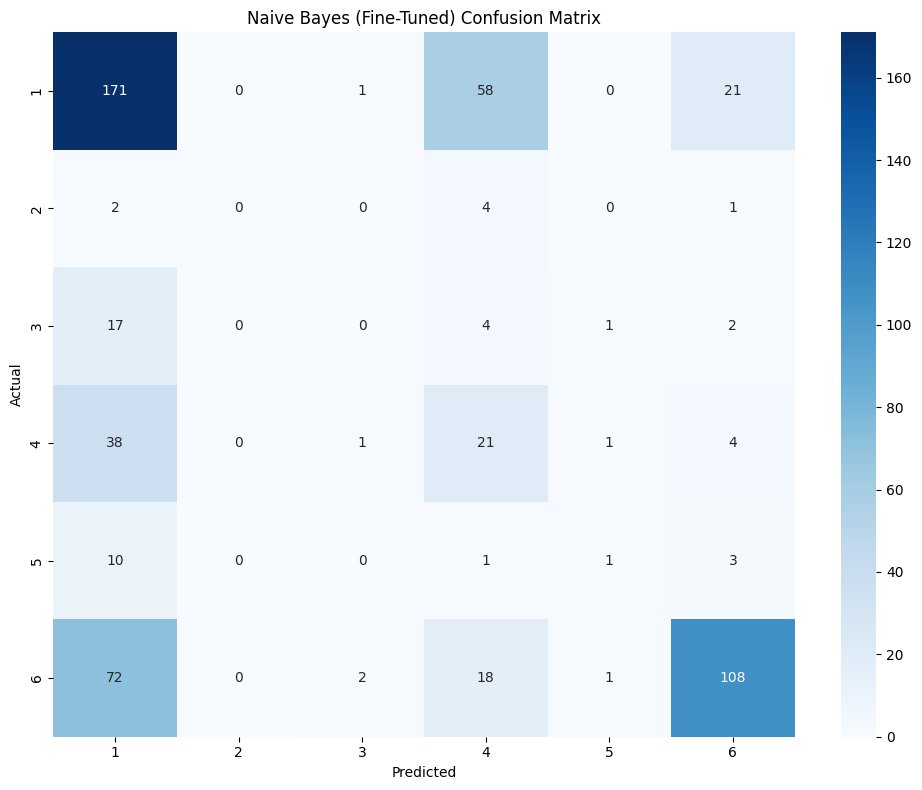


Naive Bayes (Fine-Tuned) LIME Explanations:
Prediction error: 'randomforestclassifier'
LIME Explanation Error: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.naive_bayes import GaussianNB

# Fine-tune Naive Bayes
nb_param_grid = {
    'gaussiannb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

nb_model = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    GaussianNB()
)

nb_grid = GridSearchCV(nb_model, nb_param_grid, scoring='accuracy', cv=3, verbose=1)
nb_grid.fit(X_train, y_train)

# Evaluate the fine-tuned model
evaluate_model(
    nb_grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
    "Naive Bayes (Fine-Tuned)",
    label_encoder
)


The fine-tuned Naive Bayes classifier demonstrates moderate performance with 53% accuracy and a weighted average F1-score of 0.53, comparable to but slightly lower than the kNN model. Class 6 shows the best precision (0.78) with decent recall (0.54), resulting in an F1-score of 0.64, while Class 1 maintains balanced performance with 0.55 precision and 0.68 recall (F1-score 0.61). The confusion matrix reveals that Class 1 correctly classified 171 out of 251 samples, and Class 6 correctly identified 108 out of 201 samples. However, there's significant misclassification between these classes, with 72 instances of Class 6 being incorrectly labeled as Class 1. The model particularly struggles with minority classes (2, 3, and 5) showing zero or near-zero performance metrics, likely due to severe class imbalance (having only 7, 24, and 15 samples respectively). Class 4 shows modest improvement over the kNN model with higher recall (0.32) but still poor precision (0.20), and the confusion matrix shows substantial misclassification of Class 4 instances as Class 1 (38 samples) and Class 6 (4 samples). This suggests that while the Naive Bayes model handles some aspects better than kNN, it still suffers from similar class imbalance issues and would benefit from techniques like SMOTE for minority class oversampling or class weight adjustment.

<ipython-input-27-99510e79a016>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='Accuracy', palette='viridis')


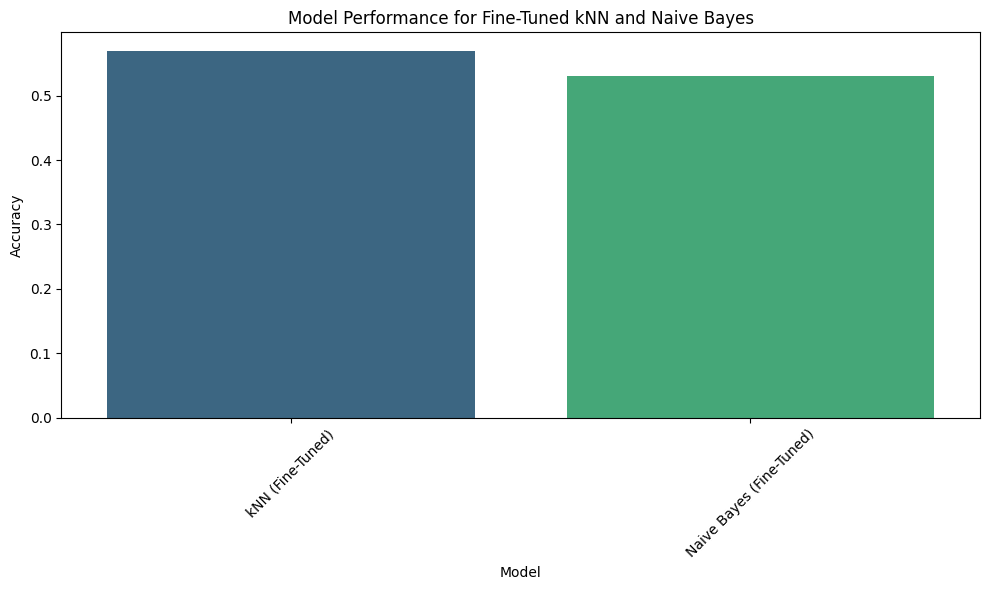

In [27]:
# Collect performance metrics
performance_metrics = {
    'Model': [
        'kNN (Fine-Tuned)',
        'Naive Bayes (Fine-Tuned)'
    ],
    'Accuracy': [0.57, 0.53]
}

# Create DataFrame for visualization
performance_df = pd.DataFrame(performance_metrics)

# Plot bar graph
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Performance for Fine-Tuned kNN and Naive Bayes')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Two classifiers, k-Nearest Neighbors (kNN) and Naive Bayes, were fine-tuned to optimize their performance. For kNN, parameters such as the number of neighbors (n_neighbors) and weighting scheme (weights) were tuned using GridSearchCV, with candidate values of 3, 5, 7, and 9 for n_neighbors, and options of uniform and distance for weights. Similarly, for Naive Bayes, the smoothing parameter (var_smoothing) was fine-tuned across values of $1 \times 10^{-9}$, $1 \times 10^{-8}$, $1 \times 10^{-7}$, and $1 \times 10^{-6}$ Both models were evaluated using a pipeline incorporating median imputation and standard scaling to preprocess the data. The fine-tuned models were then assessed using a classification report to understand their performance.

The kNN model achieved an overall accuracy of 57% but displayed imbalanced performance, performing well on class 1 (precision of 55%, recall of 80%) and class 6 (precision of 69%, recall of 57%) but poorly on others. This indicates kNN's limitations in handling imbalanced datasets, where minority classes (e.g., 2, 3, and 5) were poorly predicted. For Naive Bayes, the accuracy was slightly lower at 53%, with better performance on class 1 and class 6 but limited predictive ability for minority classes. The overall macro-average metrics for both models were low, highlighting significant disparities in the model's ability to classify different loan categories fairly. These results suggest that while kNN and Naive Bayes provide some insights, additional steps, such as using more advanced techniques or addressing class imbalances, may be necessary to better detect and address biases in loan approval decisions.